In [57]:
import numpy as np
import pandas as pd
import os
import sys
import pandas as pd
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import statsmodels.api as sm




## Task 0 - Load data

We consider a farm in the region of Madrdid (arround Lat 40.5, Lon -3.75)

- SSP scenarios from Precipitation level projection from Climate Data Store (Programme of the european union) : SSP585 and SSP126 with Institut Pierre Simon Laplace (IPSL) and Max Planck Institute (MPI) for Meteorology. from 2015 to 2100
- SPI (Standardized Precipitation Index) index from Precipitation level projection from Climate Data Store : use SPI 3months cumultaive from 1980. we make the average on May, June and July each year to obtain our annual value
- crops (yield and production) from FAOSTAT : data from 1980
- crops (prices) from FAOSTAT : data from 1991
- IPAMPA Index (Agricultural means of production purchasing price index) from Insee : we use it at the inputs index
- We construct a proxies cost structure in 2020, fertilizer and pesticide utilisation from FAOSTAT and price from European Comission


Crops yields and prices

In [58]:
crops = pd.read_csv('data/FAOSTAT_crops.csv')
df_faostat_prices = pd.read_csv("data/FAOSTAT_prices.csv")

In [59]:
def crops_format(df, name):
    df = crops[crops['Item'] == name]
    df = df[['Area', 'Unit', 'Element', 'Item', 'Year', 'Value']]
    df_ = pd.pivot_table(df, index=['Item', 'Year'], columns='Element', values='Value').reset_index()
    df_ = df_.rename(columns={'Year': 'date'})
    df_ = df_[['Item', 'date', 'Area harvested', 'Yield', 'Production']]
    return df_

grapes = crops_format(crops, "Grapes")
wheat = crops_format(crops, "Wheat")
maize = crops_format(crops, "Maize (corn)")
sunflower = crops_format(crops, "Sunflower seed")

Unités de mesure :
- Yield (in kg/ha)
- Production (in t)
- Area harvested (in ha)



In [60]:
df_faostat_prices = df_faostat_prices.loc[:,["Item Code (CPC)", "Item", "Year", "Unit", "Value"]]
df_faostat_prices.rename(columns={"Year": "date"}, inplace=True)

In [61]:
grapes_prices = df_faostat_prices[df_faostat_prices["Item"] == "Grapes"].drop(columns=["Item Code (CPC)"])
maize_prices = df_faostat_prices[df_faostat_prices["Item"] == "Maize (corn)"].drop(columns=["Item Code (CPC)"])
sunflower_prices = df_faostat_prices[df_faostat_prices["Item"] == "Sunflower seed"].drop(columns=["Item Code (CPC)"])
wheat_prices = df_faostat_prices[df_faostat_prices["Item"] == "Wheat"].drop(columns=["Item Code (CPC)"])


In [62]:
def merge_price(df, price_df):
    df = pd.merge(df, price_df[['date', 'Value']], on='date', how='left')
    df = df.rename(columns={'Value': 'Price'})
    df.dropna(inplace=True)
    return df

grapes = merge_price(grapes, grapes_prices)
wheat = merge_price(wheat, wheat_prices)
maize = merge_price(maize, maize_prices)
sunflower = merge_price(sunflower, sunflower_prices)

SPI

In [63]:
SPI = pd.read_csv('data/SPI.csv')

SPI['time'] = pd.to_datetime(SPI['time'])

SPI = SPI.rename(columns={'SPI3': 'SPI'})

SPI['year'] = SPI['time'].dt.year
SPI_index = SPI.groupby('year')['SPI'].mean().reset_index()
SPI_index = SPI_index.rename(columns={'year': 'date'})

# Formater la date avec l'année-mois-jour heure (01-01 00:00:00)
SPI_index['date'] = pd.to_datetime(SPI_index['date'].astype(str))

IPAMPA Index

In [64]:
ipampa_overall_index = pd.read_csv("data/IPAMPA_overall_index.csv", sep=";")
ipampa_overall_index.rename(columns={"Label": "date", "Annual agricultural means of production purchasing price index (IPAMPA) - Overall index": "IPAMPA_overall_index"}, inplace=True)

## Task 1
WE construct a farm, the repartition of production is the following:
- total = 70 ha
- 20% sunflower
- 30% maize
- 20% grapes
- 30% wheat

We compute the outputs (Revenue, Costs and Margin)


In [65]:
weights = {"Grapes": 0.2, "Maize (corn)": 0.3, "Sunflower seed": 0.2, "Wheat": 0.3}
total = 20 #ha
ha_grapes = total * weights["Grapes"]
ha_maize = total * weights["Maize (corn)"]
ha_sunflower = total * weights["Sunflower seed"]
ha_wheat = total * weights["Wheat"]

Total Yiels for each crop in the farm (in t for 70 ha)

In [66]:
grapes["Yield_tot"] = grapes["Yield"] * ha_grapes * 0.001 #en tonnes
maize["Yield_tot"] = maize["Yield"] * ha_maize * 0.001 #en tonnes
sunflower["Yield_tot"] = sunflower["Yield"] * ha_sunflower * 0.001 #en tonnes
wheat["Yield_tot"] = wheat["Yield"] * ha_wheat * 0.001 #en tonnes

Total Revenu for each crop in the farm (in $ for 70 ha)

In [67]:
grapes["Revenue"] = grapes["Yield_tot"] * grapes["Price"]
wheat["Revenue"] = wheat["Yield_tot"] * wheat["Price"]
maize["Revenue"] = maize["Yield_tot"] * maize["Price"]
sunflower["Revenue"] = sunflower["Yield_tot"] * sunflower["Price"]


In [68]:
flows= pd.concat([grapes[['date', 'Revenue']], wheat[['date', 'Revenue']], maize[['date', 'Revenue']], sunflower[['date', 'Revenue']]])
flows = flows.groupby('date')['Revenue'].sum().reset_index()


We imagine some cost (inputs) of the farmer (we did not include earnings, taxes, ...)

The IPAMPA Index is in base 100 = 2020, so we imagine a cost tructure in 2020, and it will evoluate with the idex IPAMPA

- Fertilisation (Azote, P, K) = 175 € (35.35 %)
- Phytosanitaires = 45 € (9.09 %)
- Semences = 70 € (14.14 %)
- Carburant (GNR) = 65 € (13.13 %)
- Séchage / Divers = 45 € (9.09 %)
- Main d'oeuvre = 95 € (19.19 %)

Total = 595 euros = 0.88 * 595 \$ = 523.6 \$ de coûts en 2020.

We can easily deduce the historic of costs


In [69]:
#ipampa_overall_index["Cost"] = 523.6 * 20 * 100 / ipampa_overall_index["IPAMPA_overall_index"]
ipampa_overall_index["Cost"] = 523.6 * 20 * ipampa_overall_index["IPAMPA_overall_index"] /100

We compute the Margin ( = Revenue - Costs) in $

In [70]:
flows = pd.merge(flows, ipampa_overall_index[['date', 'Cost', 'IPAMPA_overall_index']], left_on='date', right_on='date', how='left')
flows.dropna(inplace=True)
flows['Margin'] = flows['Revenue'] - flows['Cost']
flows.rename(columns={'IPAMPA_overall_index': 'IPAMPA'}, inplace=True)
flows


,date,Revenue,Cost,IPAMPA,Margin
14,2005,25572.65536,8178.632,78.1,17394.02336
15,2006,30007.06186,8409.016,80.3,21598.04586
16,2007,41420.14590,8880.256,84.8,32539.88990
17,2008,41620.54626,10074.064,96.2,31546.48226
18,2009,33638.76360,9435.272,90.1,24203.49160
19,2010,41966.25258,9487.632,90.6,32478.62058
20,2011,50021.26774,10346.336,98.8,39674.93174
21,2012,43948.16892,10660.496,101.8,33287.67292
22,2013,51890.03484,10765.216,102.8,41124.81884
23,2014,50754.52500,10503.416,100.3,40251.10900


## Task 2

We have to define wet and dry threshold, so we compute the distribution of the SPI

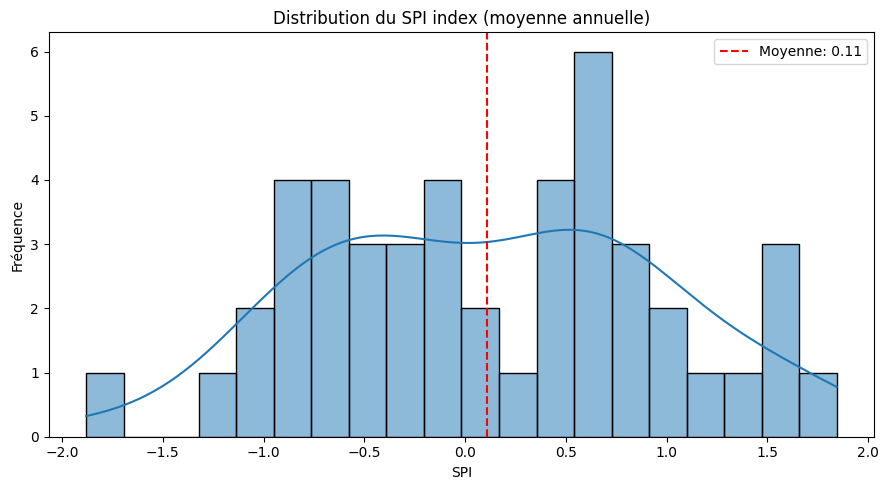

count    46.000000
mean      0.111135
std       0.856195
min      -1.880435
25%      -0.594034
50%       0.041024
75%       0.675057
max       1.844582
Name: SPI, dtype: float64

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution du SPI index annuel
plt.figure(figsize=(9, 5))
sns.histplot(SPI_index['SPI'].dropna(), bins=20, kde=True)
plt.axvline(SPI_index['SPI'].mean(), color='red', linestyle='--', label=f"Moyenne: {SPI_index['SPI'].mean():.2f}")
plt.title('Distribution du SPI index (moyenne annuelle)')
plt.xlabel('SPI')
plt.ylabel('Fréquence')
plt.legend()
plt.tight_layout()
plt.show()

SPI_index['SPI'].describe()

#### Comments :
- We take -0.5 as the threshold to remain consistent with the article Probabilistic estimates of the impacts of drought on agricultural production and since the first quartile of the distribution of values ​​of the drought indicator is equal to -0.6, it is significant to take 0.5.

We compute a barplot of the SPI index, to show the drought episods

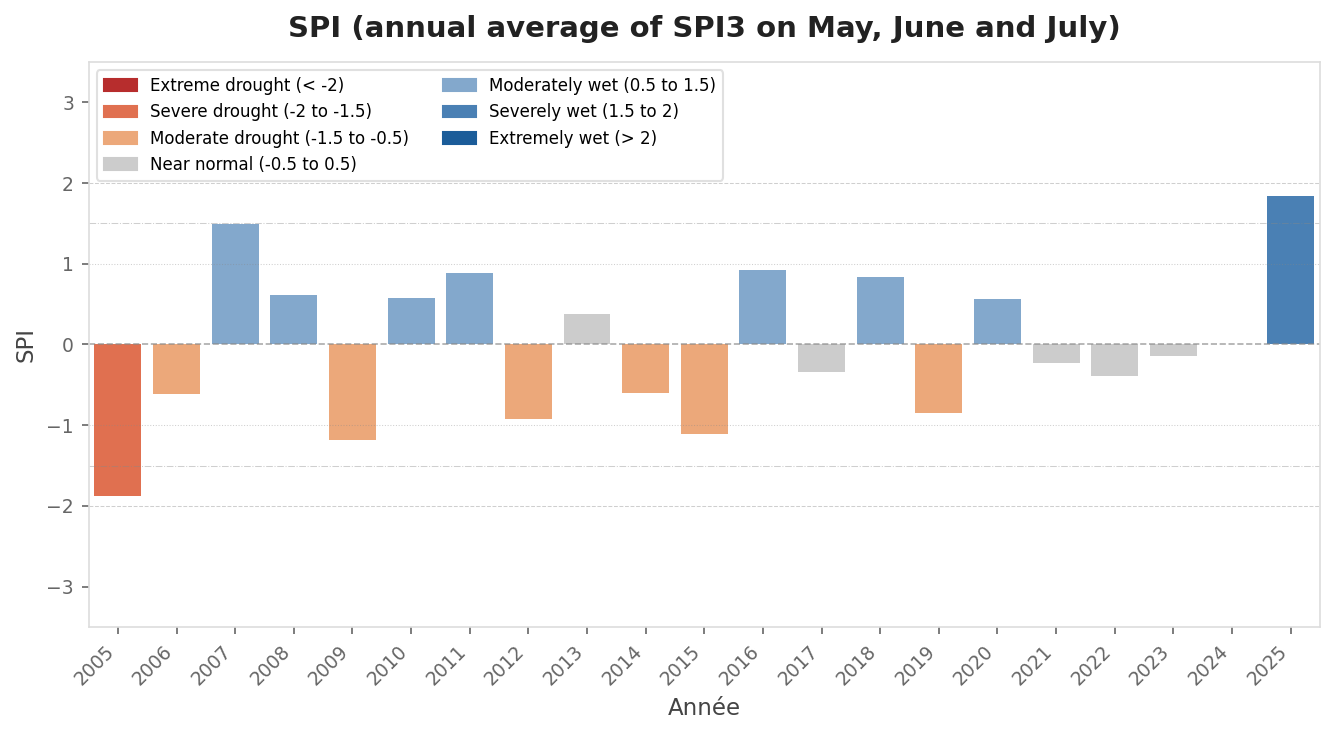

In [72]:
"""
Visualisation du SPI annuel à partir de data/SPI.csv
Le fichier contient: time, lat, lon, SPI3 (3 mois).
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ─────────────────────────────────────────────
# PARAMÈTRES
# ─────────────────────────────────────────────
FICHIER_SPI = "data/SPI.csv"
DPI = 150

# Catégories SPI (OMM)
BINS = [-np.inf, -2.0, -1.5, -0.5, 0.5, 1.5, 2.0, np.inf]
COLORS = ["#B72D2D", "#E07050", "#ECA87A", "#CCCCCC", "#83A8CC", "#4A80B4", "#1B5C99"]
LABELS = [
    "Extreme drought (< -2)",
    "Severe drought (-2 to -1.5)",
    "Moderate drought (-1.5 to -0.5)",
    "Near normal (-0.5 to 0.5)",
    "Moderately wet (0.5 to 1.5)",
    "Severely wet (1.5 to 2)",
    "Extremely wet (> 2)",
]

def couleur_spi(valeur):
    for i in range(len(BINS) - 1):
        if BINS[i] <= valeur < BINS[i + 1]:
            return COLORS[i]
    return COLORS[3]

# ─────────────────────────────────────────────
# CHARGEMENT + AGRÉGATION ANNUELLE (via colonne date)
# ─────────────────────────────────────────────
df = pd.read_csv(FICHIER_SPI)
df["time"] = pd.to_datetime(df["time"], errors="coerce")
df = df.dropna(subset=["time", "SPI3"])
df = df[df["time"].dt.year >= 2005]

df["date"] = df["time"].dt.to_period("Y").dt.to_timestamp()

df_a = df.groupby("date", as_index=False)["SPI3"].mean()
df_a = df_a.rename(columns={"SPI3": "spi_annuel"})
df_a["year"] = df_a["date"].dt.year

# ─────────────────────────────────────────────
# FIGURE : SPI ANNUEL
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5), dpi=DPI)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

colors_a = [couleur_spi(v) for v in df_a["spi_annuel"]]
ax.bar(df_a["year"], df_a["spi_annuel"], color=colors_a, width=0.8, linewidth=0)

# Ligne zéro + seuils
ax.axhline(0, color="#888888", linewidth=0.8, linestyle="--", alpha=0.7)
for seuil, ls in [(-1, ":"), (-1.5, "-."), (-2, "--"), (1, ":"), (1.5, "-."), (2, "--")]:
    ax.axhline(seuil, color="#888888", linewidth=0.5, linestyle=ls, alpha=0.4)

ax.set_xlim(df_a["year"].min() - 0.5, df_a["year"].max() + 0.5)
ax.set_ylim(-3.5, 3.5)
ax.set_xticks(df_a["year"])
ax.set_xticklabels(df_a["year"], rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Année", fontsize=11, color="#444")
ax.set_ylabel("SPI", fontsize=11, color="#444")
ax.set_title("SPI (annual average of SPI3 on May, June and July)", fontsize=14, fontweight="bold", pad=12, color="#222")

ax.tick_params(colors="#666", labelsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor("#dddddd")

patches = [mpatches.Patch(color=c, label=l) for c, l in zip(COLORS, LABELS)]
ax.legend(
    handles=patches,
    loc="upper left",
    fontsize=8,
    framealpha=0.9,
    edgecolor="#dddddd",
    ncol=2,
)

plt.tight_layout()


#### Comment :
- The annual mean of SPI3 does not suggest a simple monotonic increase in drought exposure over time. Instead, it points to strong interannual variability, with alternating dry and wet years throughout the sample. Several years stand out as clearly dry, notably 2005 and then again around 2012–2015, which appears to be the most sustained relatively dry phase in the series. At the same time, this pattern is repeatedly interrupted by wetter years such as 2007, 2008, 2010, 2011, 2016, 2018, 2020, and especially 2025. 
- Overall, the series suggests recurrent exposure to drought episodes rather than a continuous worsening trend. That said, because this indicator is based on average of the SPI3 on May, June and July, it smooths short-term and seasonal extremes: a year with severe summer drought may still appear close to normal if wetter conditions prevail during the rest of the year. As a result, the figure is best interpreted as showing broad annual hydro-climatic fluctuations rather than the full intensity or persistence of drought conditions.

## Task 3

We use a graph to show the links between drought intensity and yield evolution

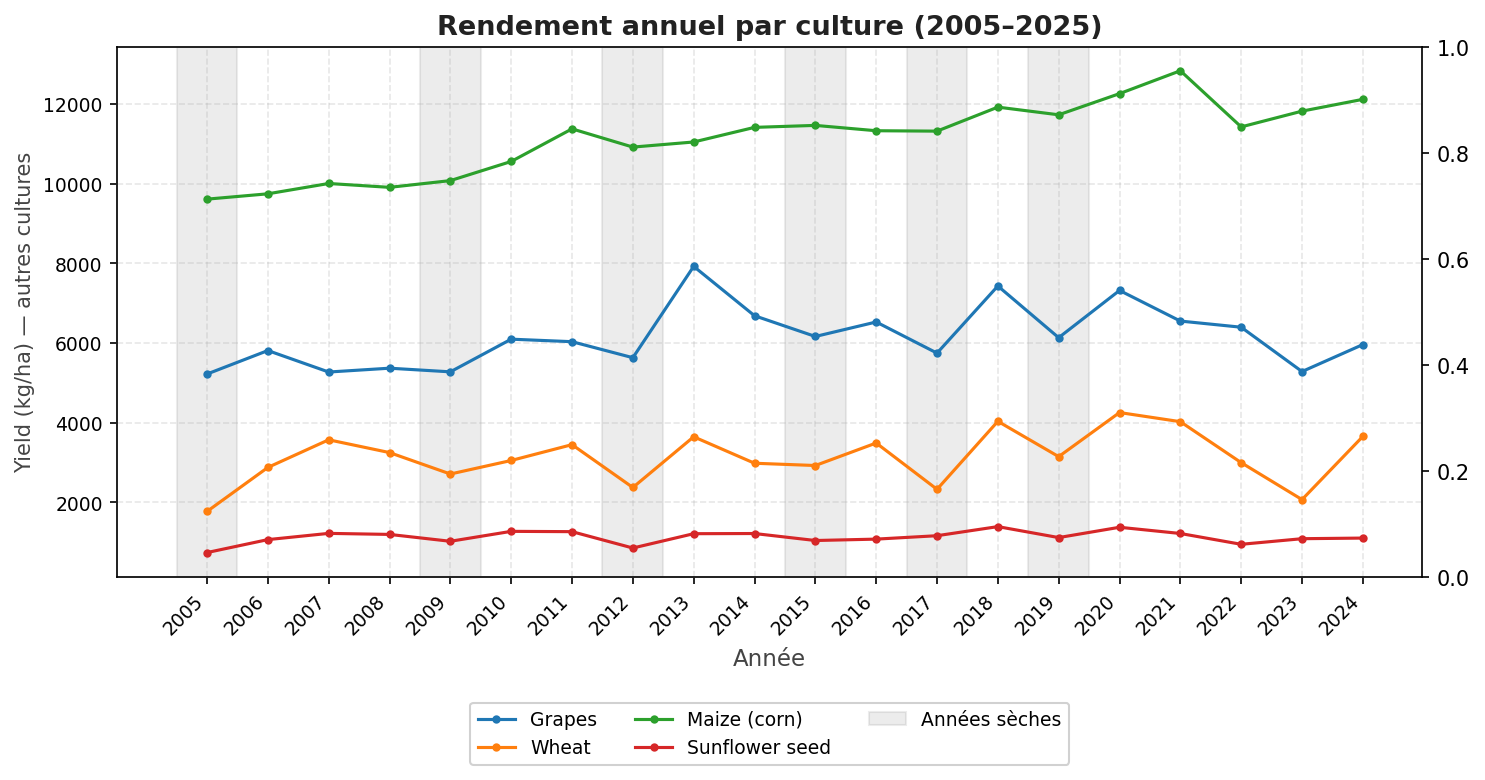

In [73]:
crops_left = {
    "Grapes": grapes,
    "Wheat": wheat,
    "Maize (corn)": maize,
    "Sunflower seed": sunflower,
}

dry_years = [2005, 2009, 2012, 2015, 2017, 2019]

fig, ax1 = plt.subplots(figsize=(10, 5), dpi=150)
ax2 = ax1.twinx()

# Bandes grises pour années sèches (en arrière-plan)
for yr in dry_years:
    ax1.axvspan(yr - 0.5, yr + 0.5, color="gray", alpha=0.15, zorder=0)

# Cultures sur axe gauche
for name, df_crop in crops_left.items():
    df_filtered = df_crop[df_crop["date"] >= 2005].dropna(subset=["Yield"])
    ax1.plot(df_filtered["date"], df_filtered["Yield"], marker="o", markersize=3, linewidth=1.5, label=name)


# Ticks années entières
all_years = sorted(grapes[grapes["date"] >= 2005]["date"].unique())
ax1.set_xticks(all_years)
ax1.set_xticklabels(all_years, rotation=45, ha="right", fontsize=8)

# Axes
ax1.set_xlabel("Année", fontsize=11, color="#444")
ax1.set_ylabel("Yield (kg/ha) — autres cultures", fontsize=10, color="#444")

ax1.set_title("Rendement annuel par culture (2005–2025)", fontsize=13, fontweight="bold", color="#222")

# Légende combinée — placée en dehors du graphique, en bas
dry_patch = mpatches.Patch(color="gray", alpha=0.15, label="Années sèches")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + [dry_patch], labels1 + labels2 + ["Années sèches"], fontsize=9, framealpha=0.9,
           loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=3)

ax1.tick_params(labelsize=9)
for spine in ax1.spines.values():
    spine.set_edgecolor("#dddddd")


# Grille légère
ax1.grid(True, alpha=0.3, linestyle='--')


plt.tight_layout()
plt.subplots_adjust(bottom=0.22)
plt.show()


#### Comments :
- We remark that drought intensity implied important yield losses particularly for the wheat and the grapes (in 2012, 2017 for example).

We model conditional probability density functions of crop yields in wet (SPI >= 0.5; blue) and
dry (SPI < 0.5; orange) conditions for each of the crops in the farm.

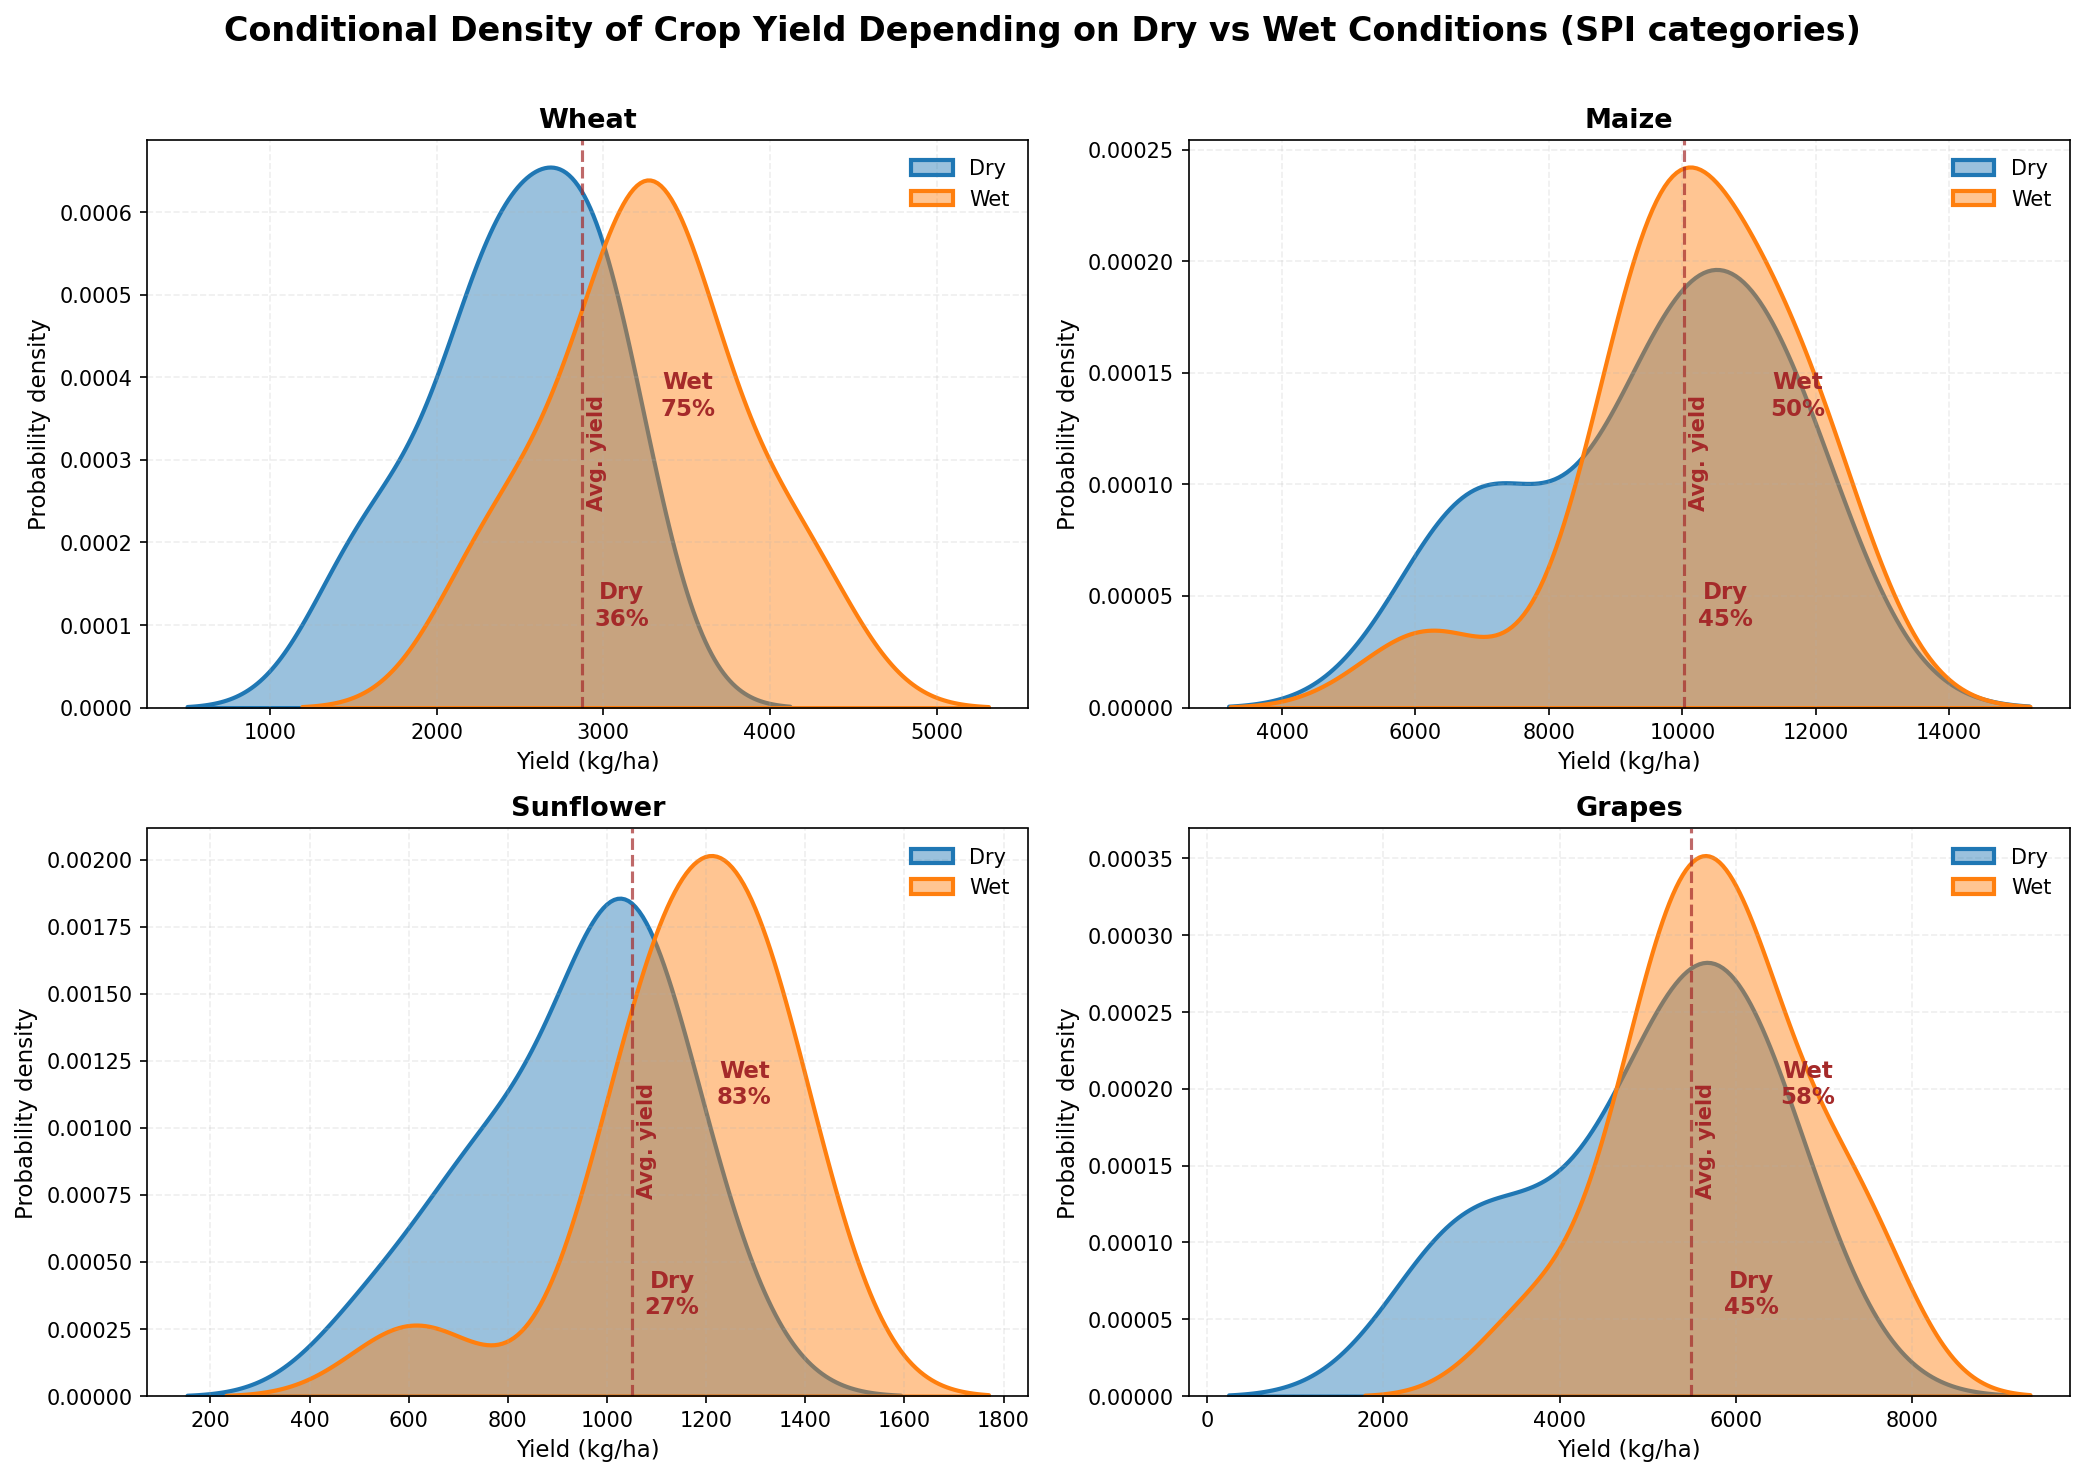

In [74]:
SPI = SPI_index.copy()
SPI['date'] = pd.to_datetime(SPI['date']).dt.year
SPI = SPI[['date', 'SPI']].dropna().groupby('date', as_index=False)['SPI'].mean()

crops = {
    'Wheat': wheat.copy(),
    'Maize': maize.copy(),
    'Sunflower': sunflower.copy(),
    'Grapes': grapes.copy()
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=150)
axes = axes.flatten()

for ax, (crop_name, df) in zip(axes, crops.items()):
    df = df.copy()
    df['date'] = df['date'].astype(int)

    df = df.drop(columns=['SPI'], errors='ignore')
    df = df.merge(SPI, on='date', how='left')

    df_dry = df[df['SPI'] < -0.5].copy()
    df_wet = df[df['SPI'] >= 0.5].copy()

    avg_yield = df['Yield'].mean()
    x_range = df['Yield'].max() - df['Yield'].min()

    x_range = df['Yield'].max() - df['Yield'].min()

    # KDE dry / wet
    sns.kdeplot(
        data=df_dry,
        x='Yield',
        label='Dry',
        fill=True,
        alpha=0.45,
        linewidth=2,
        ax=ax
    )

    sns.kdeplot(
        data=df_wet,
        x='Yield',
        label='Wet',
        fill=True,
        alpha=0.45,
        linewidth=2,
        ax=ax
    )

    # Ligne verticale moyenne
    ax.axvline(avg_yield, linestyle='--', linewidth=1.5, color='brown', alpha=0.7)


    dry_den = len(df_dry.dropna(subset=['Yield']))
    wet_den = len(df_wet.dropna(subset=['Yield']))

    dry_pct = (len(df_dry[df_dry['Yield'] > avg_yield]) / dry_den * 100) if dry_den > 0 else 0
    wet_pct = (len(df_wet[df_wet['Yield'] > avg_yield]) / wet_den * 100) if wet_den > 0 else 0


    offsets = {
        'Wheat': (650, 250),
        'Maize': (900, 1700),
        'Sunflower': (120, 70),
        'Grapes': (900, 1000)
    }

    # Texte moyenne
    ax.text(
        avg_yield + 0.01 * x_range,
        ax.get_ylim()[1] * 0.45,
        'Avg. yield',
        rotation=90,
        va='center',
        ha='left',
        fontsize=10,
        fontweight='bold',
        color='brown'
    )

    # Annotations
    if len(df_dry) > 0:
        ax.text(
            df_dry['Yield'].median() + offsets[crop_name][0],
            ax.get_ylim()[1] * 0.18,
            f"Dry\n{dry_pct:.0f}%",
            ha='center',
            va='center',
            fontsize=11,
            fontweight='bold',
            color='brown'
        )

    if len(df_wet) > 0:
        ax.text(
            df_wet['Yield'].median() + offsets[crop_name][1],
            ax.get_ylim()[1] * 0.55,
            f"Wet\n{wet_pct:.0f}%",
            ha='center',
            va='center',
            fontsize=11,
            fontweight='bold',
            color='brown'
        )

    ax.set_title(f'{crop_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Yield (kg/ha)', fontsize=11)
    ax.set_ylabel('Probability density', fontsize=11)
    ax.grid(alpha=0.2, linestyle='--')
    ax.legend(frameon=False)

plt.suptitle('Conditional Density of Crop Yield Depending on Dry vs Wet Conditions (SPI categories)', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

#### Comments:
- For each crop over from 1980, the probability of yields exceeding annual average production is larger in wet conditions tha, in dry conditions.
For example, the probability of annual wheat production exceeding its average yield is 27 % in dry condi-
tions (SPI < -0.5) and 83% in wet conditions (SPI >= 0.5).
- Generally, drought risk on the annual production of maize and grapes are less than the other two crops (wheat and sunflower).

## Task 4

Now we want to study the drought intensity impact on the financial flows, so we compute the variation (%) of the revenue, costs and margin flows.

In [75]:
flows_returns = flows.copy()
flows_returns['Revenue'] = flows_returns['Revenue'].pct_change().dropna()*100
flows_returns['Cost'] = flows_returns['Cost'].pct_change().dropna()*100
flows_returns['Margin'] = flows_returns['Margin'].pct_change().dropna()*100
flows_returns['IPAMPA'] = flows_returns['IPAMPA'].pct_change().dropna()*100
flows_returns = flows_returns.dropna()


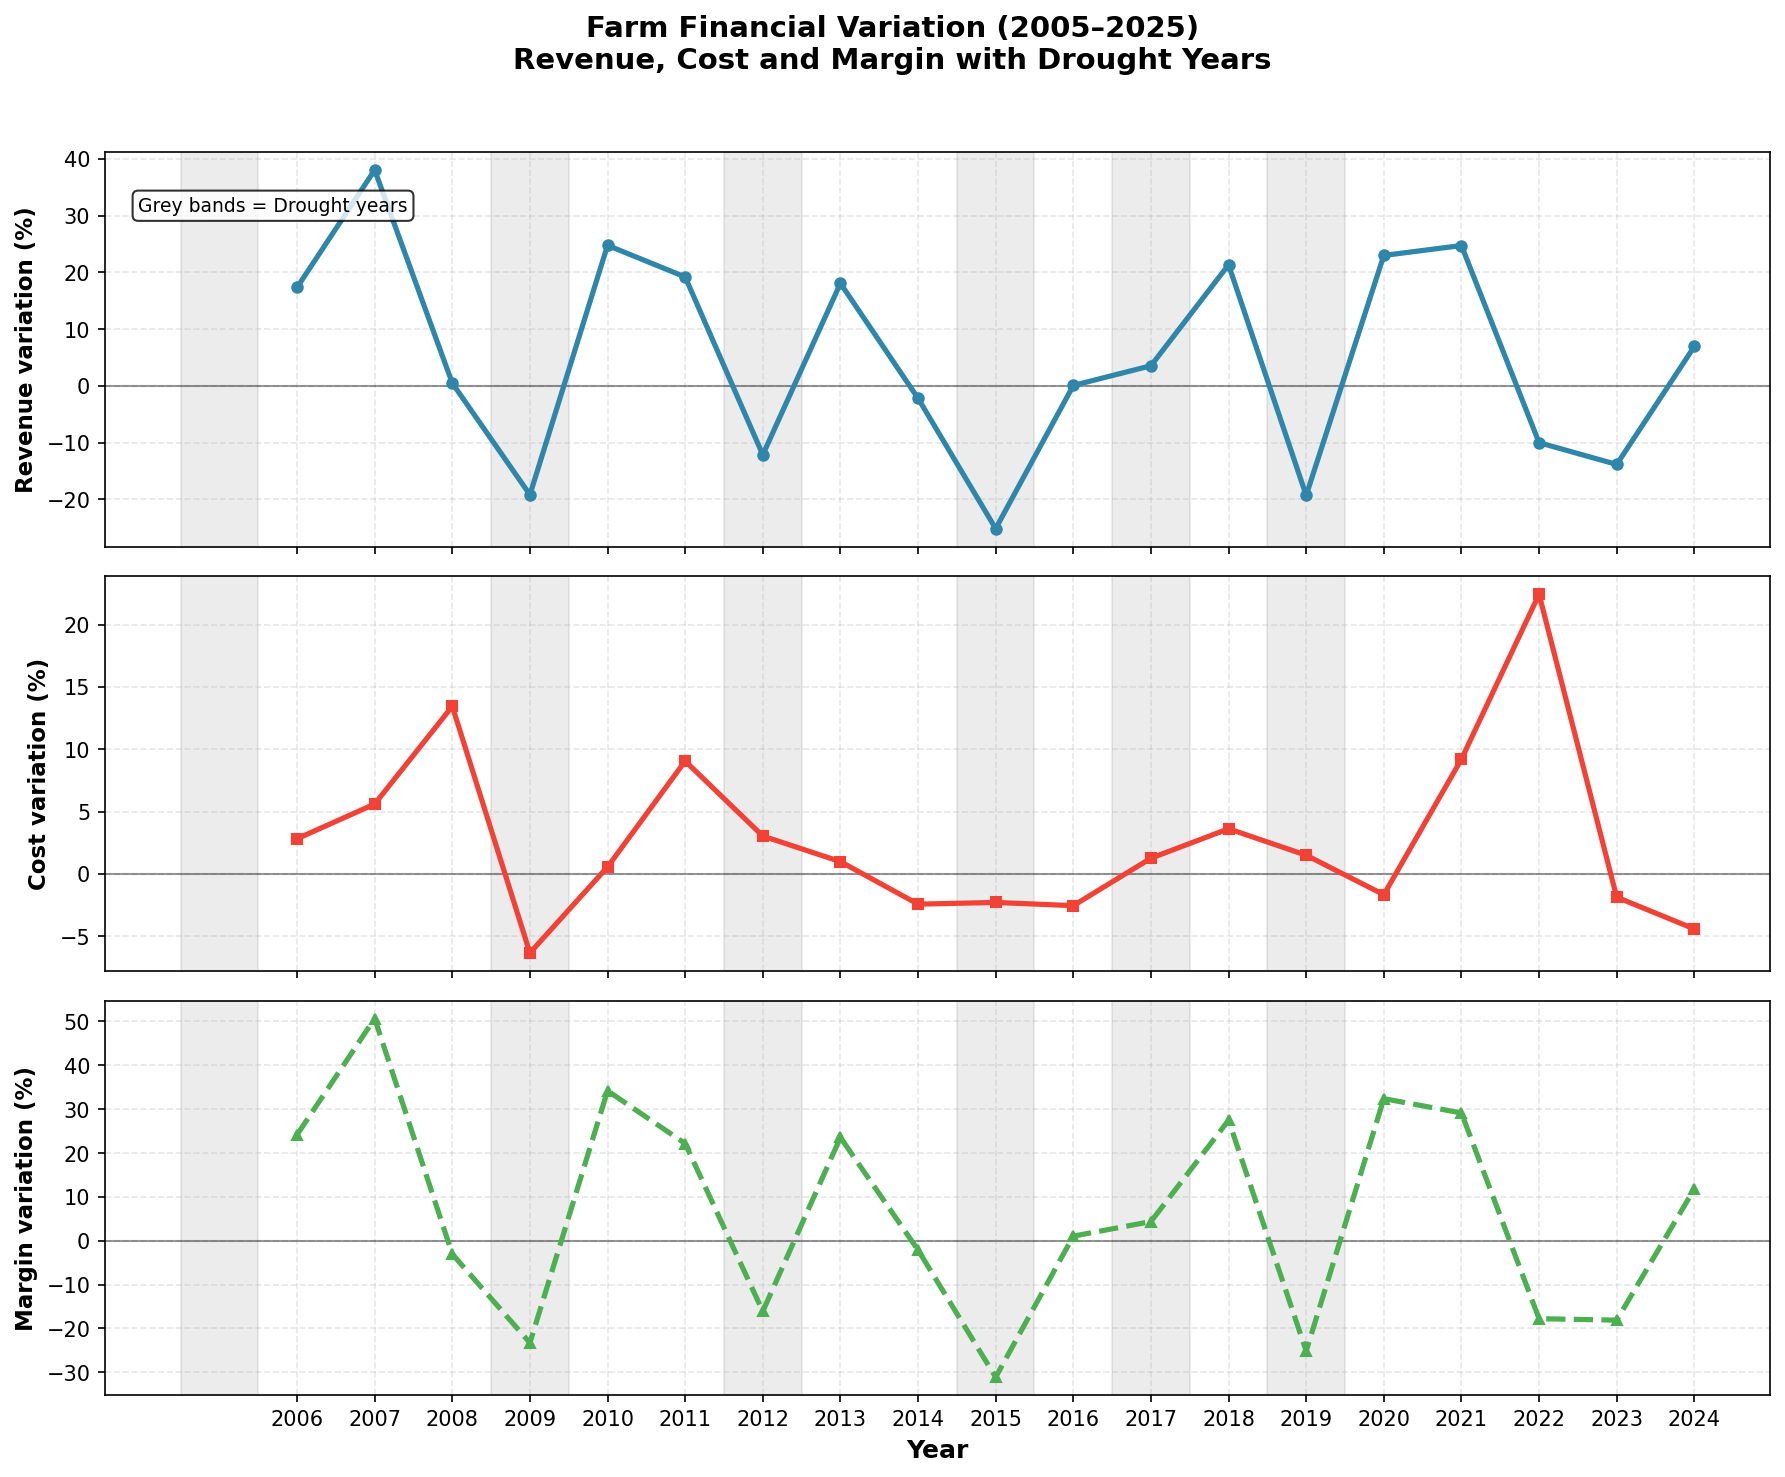

In [76]:
dry_years = [2005, 2009, 2012, 2015, 2017, 2019]

fig, axes = plt.subplots(3, 1, figsize=(12, 10), dpi=150, sharex=True)

# Données
flows_returns['Revenue_USD'] = flows_returns['Revenue']
flows_returns['Cost_USD'] = flows_returns['Cost']
flows_returns['Margin_USD'] = flows_returns['Margin']

titles = ['Revenue variation (%)', 'Cost variation (%)', 'Margin variation (%)']
colors = ['#2E86AB', '#F24236', '#4CAF50']
markers = ['o', 's', '^']
linestyles = ['-', '-', '--']
variables = ['Revenue_USD', 'Cost_USD', 'Margin_USD']

for ax, var, title, color, marker, ls in zip(axes, variables, titles, colors, markers, linestyles):

    # Bandes sécheresse
    for yr in dry_years:
        ax.axvspan(yr - 0.5, yr + 0.5, color="gray", alpha=0.15, zorder=0)

    # Courbe
    ax.plot(
        flows_returns['date'],
        flows_returns[var],
        linewidth=2.5,
        marker=marker,
        markersize=5,
        linestyle=ls,
        color=color,
        zorder=3
    )

    # Ligne zéro (utile surtout pour margin)
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.4, linewidth=1)

    ax.set_ylabel(title, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')

# Axe X commun
axes[-1].set_xlabel('Year', fontsize=12, fontweight='bold')
axes[-1].set_xticks(flows_returns['date'])
axes[-1].set_xticklabels(flows_returns['date'].astype(int))

# Titre global
fig.suptitle(
    'Farm Financial Variation (2005–2025)\nRevenue, Cost and Margin with Drought Years',
    fontsize=14,
    fontweight='bold'
)

# Annotation globale
axes[0].text(
    0.02, 0.85,
    'Grey bands = Drought years',
    transform=axes[0].transAxes,
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

#### Comments :
- We can clearly observe that drought episodes negatively affect farm revenue variation, as well as total margin variation. This is consistent, as crop yields are adversely impacted by drought conditions.
- Regarding cost variation, the effect is more mixed. In some drought years (e.g. 2009), costs decrease, but this pattern is not systematic (e.g. 2015, 2017, and 2019). Indeed, when production declines, certain variable costs such as labor and pesticide use may also decrease. However, input prices, particularly energy, can increase, leading to higher overall costs even during drought periods (e.g., 2017). Additionally, external factors such as the Ukraine war and inflation around 2022 contributed to rising costs.

## Task 5

WE apply 2 climate scenarios, the best SSP126 and the worst SSP585,  to modify drought index (SPI)
For both scenarios we select two different models, the french one Institut Pierre Simon Laplace (IPSL) and the german one Max Planck Institute (MPI)

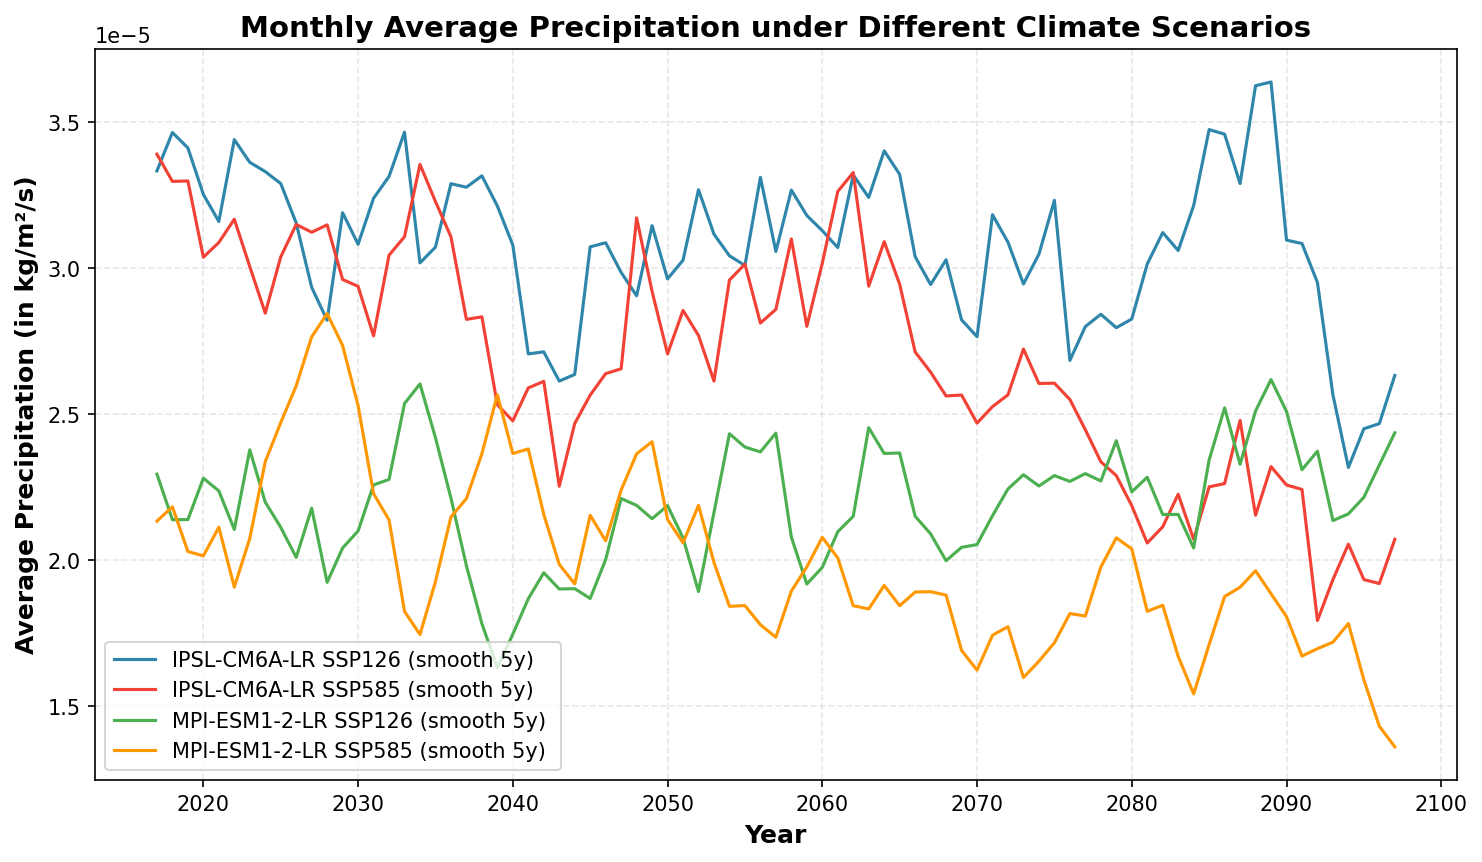

In [77]:


ipsl_ssp126 = pd.read_csv("data/IPSL-CM6A-LR_ssp126.csv")
ipsl_ssp126['time'] = pd.to_datetime(ipsl_ssp126['time'], errors='coerce')
# moyenne des pr par année
ipsl_ssp126['year'] = ipsl_ssp126['time'].dt.year
ipsl_ssp126_yearly = ipsl_ssp126.groupby('year')['pr'].mean().reset_index()
ipsl_ssp126_yearly['pr_smooth'] = ipsl_ssp126_yearly['pr'].rolling(window=5, center=True).mean()


ipsl_ssp585 = pd.read_csv("data/IPSL-CM6A-LR_ssp585.csv")
ipsl_ssp585['time'] = pd.to_datetime(ipsl_ssp585['time'], errors='coerce')
ipsl_ssp585['year'] = ipsl_ssp585['time'].dt.year
ipsl_ssp585_yearly = ipsl_ssp585.groupby('year')['pr'].mean().reset_index()
ipsl_ssp585_yearly['pr_smooth'] = ipsl_ssp585_yearly['pr'].rolling(window=5, center=True).mean()

mpi_ssp126 = pd.read_csv("data/MPI-ESM1-2-LR_ssp126.csv")
mpi_ssp126['time'] = pd.to_datetime(mpi_ssp126['time'], errors='coerce')
mpi_ssp126['year'] = mpi_ssp126['time'].dt.year
mpi_ssp126_yearly = mpi_ssp126.groupby('year')['pr'].mean().reset_index()
mpi_ssp126_yearly['pr_smooth'] = mpi_ssp126_yearly['pr'].rolling(window=5, center=True).mean()

mpi_ssp585 = pd.read_csv("data/MPI-ESM1-2-LR_ssp585.csv")
mpi_ssp585['time'] = pd.to_datetime(mpi_ssp585['time'], errors='coerce')
mpi_ssp585['year'] = mpi_ssp585['time'].dt.year
mpi_ssp585_yearly = mpi_ssp585.groupby('year')['pr'].mean().reset_index()
mpi_ssp585_yearly['pr_smooth'] = mpi_ssp585_yearly['pr'].rolling(window=5, center=True).mean()
#plot
plt.figure(figsize=(10, 6), dpi=150)
plt.plot(ipsl_ssp126_yearly['year'], ipsl_ssp126_yearly['pr_smooth'], label='IPSL-CM6A-LR SSP126 (smooth 5y) ', color='#2E86AB')
plt.plot(ipsl_ssp585_yearly['year'], ipsl_ssp585_yearly['pr_smooth'], label='IPSL-CM6A-LR SSP585 (smooth 5y) ', color='#F24236')
plt.plot(mpi_ssp126_yearly['year'], mpi_ssp126_yearly['pr_smooth'], label='MPI-ESM1-2-LR SSP126 (smooth 5y) ', color='#4CAF50')
plt.plot(mpi_ssp585_yearly['year'], mpi_ssp585_yearly['pr_smooth'], label='MPI-ESM1-2-LR SSP585 (smooth 5y) ', color='#FF9800')
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Average Precipitation (in kg/m²/s)', fontsize=12, fontweight='bold')
plt.title('Monthly Average Precipitation under Different Climate Scenarios', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()



#### Comments :

- We can clearly observe that, in both models, the SSP126 scenario generally implies higher precipitation levels than the SSP585 scenario, particularly from around 2050 onwards. This is consistent, as SSP585 represents a more severe climate change pathway with stronger warming and associated drying effects in some regions.
- However, there is a noticeable difference in magnitude between the two models: the IPSL model shows higher overall precipitation levels compared to the MPI model.
- Within the MPI model, we can observe some inconsistencies between the two scenarios. For instance, around 2035, precipitation decreases under SSP585 while it increases under SSP126, leading to a divergence that is not entirely smooth. Given these discrepancies, we will focus the analysis on the IPSL model, which appears more consistent for our purposes.

We compute the SPI3 from the precipitation predictions over 2015-2100. For each scenarios we copute the SPI3
- (Distribution fitting) For each calendar month (January, February, etc.), we fit a Gamma distribution to the values.
- (Probability transformation) we compute the CDF of the fitted Gamma distribution and adjusted to account for zero precipitation values.
- (Standardization) we transform the probabilities into a standard normal distribution using the inverse normal function. The values obtaining are the SPI values
SPI < -0.5 → dry conditions
SPI >= 0.5 → wet conditions

In [78]:
import pandas as pd
import numpy as np
from scipy.stats import gamma, norm

def compute_spi(df):
    df = df[['time', 'pr']].copy()
    df['time'] = pd.to_datetime(df['time'], errors='coerce')
    df = df.dropna(subset=['time']).sort_values('time').reset_index(drop=True)

    df['year'] = df['time'].dt.year
    df['month'] = df['time'].dt.month

    # Conversion kg/m²/s -> mm/mois (plus précis que 30 jours fixes)
    df['days_in_month'] = df['time'].dt.days_in_month
    df['pr_mm'] = df['pr'] * 86400 * df['days_in_month'] #kg/m²/s in mm/s

    # SPI-3 : cumul sur 3 mois
    df['pr_3m'] = df['pr_mm'].rolling(window=3).sum()

    # Colonne résultat
    df['SPI_gamma'] = np.nan

    # Calcul par mois du calendrier
    for m in range(1, 13):
        mask = df['month'] == m
        subset = df.loc[mask, ['pr_3m']].copy()

        # Enlever les NaN avant fit
        valid = subset['pr_3m'].dropna()

        # Trop peu de données -> on saute
        if len(valid) < 10:
            continue

        # La gamma exige des valeurs strictement positives
        valid = valid[valid > 0]
        if len(valid) < 10:
            continue

        # Ajustement Gamma
        shape, loc, scale_param = gamma.fit(valid, floc=0)

        # CDF sur toutes les valeurs du sous-ensemble
        cdf = gamma.cdf(subset['pr_3m'], a=shape, loc=loc, scale=scale_param)

        # Correction zéros
        q = (subset['pr_3m'] <= 0).sum() / subset['pr_3m'].notna().sum()
        cdf = q + (1 - q) * cdf

        # Éviter 0 et 1 exacts sinon norm.ppf donne +/- inf
        cdf = np.clip(cdf, 1e-8, 1 - 1e-8)

        # Transformation en loi normale
        spi_vals = norm.ppf(cdf)

        # Réinjecter au bon endroit
        df.loc[mask, 'SPI3'] = spi_vals

    return df


ipsl_ssp126 = pd.read_csv("data/IPSL-CM6A-LR_ssp126.csv")
ipsl_ssp126 = compute_spi(ipsl_ssp126)
ipsl_ssp585 = pd.read_csv("data/IPSL-CM6A-LR_ssp585.csv")
ipsl_ssp585 = compute_spi(ipsl_ssp585,)
mpi_ssp126 = pd.read_csv("data/MPI-ESM1-2-LR_ssp126.csv")
mpi_ssp126 = compute_spi(mpi_ssp126,)
mpi_ssp585 = pd.read_csv("data/MPI-ESM1-2-LR_ssp585.csv")
mpi_ssp585 = compute_spi(mpi_ssp585)


Monthly SPI-3 values are computed over the period 2015–2100. We focus on the May–July period, which corresponds to the main crop growing season, and compute the annual SPI as the average of these three months.

In [79]:
def compute_spi_index(df):
    df = df.copy()
    df['time'] = pd.to_datetime(df['time'])
    df = df[df['time'].dt.month.isin([5, 6, 7])]
    df = df.rename(columns={'SPI3': 'SPI'})
    df['year'] = df['time'].dt.year
    df = df.groupby('year')['SPI'].mean().reset_index()
    df = df.rename(columns={'year': 'date'})
    
    return df



SPI_mpi_ssp126_index = compute_spi_index(mpi_ssp126)
SPI_mpi_ssp585_index = compute_spi_index(mpi_ssp585)
SPI_ipsl_ssp126_index = compute_spi_index(ipsl_ssp126)
SPI_ipsl_ssp585_index = compute_spi_index(ipsl_ssp585)

SPI_ipsl_ssp126_index.head(10)

,date,SPI
0,2015,-0.266550
1,2016,-0.053274
2,2017,1.209286
3,2018,0.855938
4,2019,-0.962498
5,2020,0.835974
6,2021,-0.253848
7,2022,0.911177
8,2023,1.053131
9,2024,0.169898


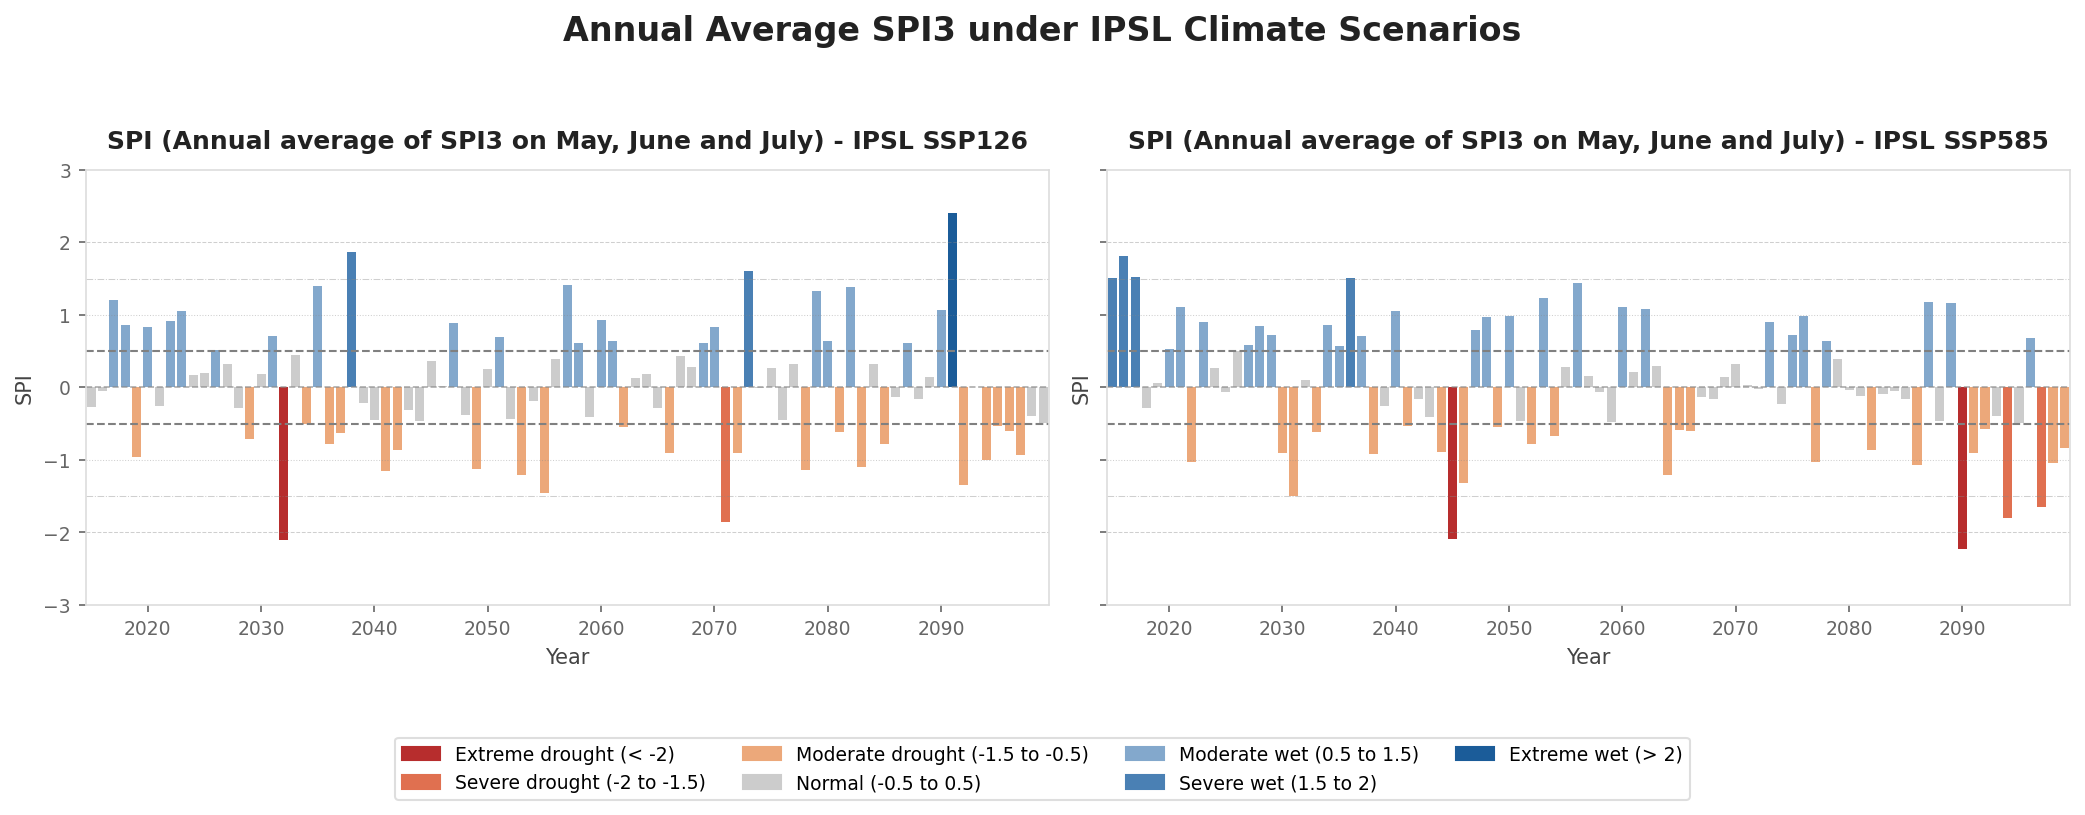

In [80]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Catégories SPI (OMM)
BINS = [-np.inf, -2.0, -1.5, -0.5, 0.5, 1.5, 2.0, np.inf]
COLORS = ["#B72D2D", "#E07050", "#ECA87A", "#CCCCCC", "#83A8CC", "#4A80B4", "#1B5C99"]
LABELS = [
    "Extreme drought (< -2)",
    "Severe drought (-2 to -1.5)",
    "Moderate drought (-1.5 to -0.5)",
    "Normal (-0.5 to 0.5)",
    "Moderate wet (0.5 to 1.5)",
    "Severe wet (1.5 to 2)",
    "Extreme wet (> 2)",
]

def couleur_spi(valeur):
    for i in range(len(BINS) - 1):
        if BINS[i] <= valeur < BINS[i + 1]:
            return COLORS[i]
    return COLORS[3]

def plot_spi_panel(ax, df, title, start_year=2015):
    df_plot = df.copy()
    df_plot = df_plot[df_plot["date"] >= start_year].copy()

    bar_colors = [couleur_spi(v) for v in df_plot["SPI"]]

    ax.set_facecolor("white")

    ax.bar(
        df_plot["date"],
        df_plot["SPI"],
        color=bar_colors,
        width=0.8,
        linewidth=0
    )

    # Seuils dry/wet
    ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)
    ax.axhline(y=-0.5, color='gray', linestyle='--', linewidth=1)

    # Ligne zéro + seuils supplémentaires
    ax.axhline(0, color="#888888", linewidth=0.8, linestyle="--", alpha=0.7)
    for seuil, ls in [(-1, ":"), (-1.5, "-."), (-2, "--"), (1, ":"), (1.5, "-."), (2, "--")]:
        ax.axhline(seuil, color="#888888", linewidth=0.5, linestyle=ls, alpha=0.4)

    ax.set_xlim(df_plot["date"].min() - 0.5, df_plot["date"].max() + 0.5)
    ax.set_ylim(-3, 3)

    ticks = df_plot["date"].unique()
    ticks_10y = ticks[ticks % 10 == 0]
    ax.set_xticks(ticks_10y)

    ax.set_xlabel("Year", fontsize=10, color="#444")
    ax.set_ylabel("SPI", fontsize=10, color="#444")
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10, color="#222")

    ax.tick_params(colors="#666", labelsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor("#dddddd")

# Figure 1x2
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=DPI, sharey=True)
fig.patch.set_facecolor("white")

plot_spi_panel(axes[0], SPI_ipsl_ssp126_index, "SPI (Annual average of SPI3 on May, June and July) - IPSL SSP126")
plot_spi_panel(axes[1], SPI_ipsl_ssp585_index, "SPI (Annual average of SPI3 on May, June and July) - IPSL SSP585")

# Légende unique
patches = [mpatches.Patch(color=c, label=l) for c, l in zip(COLORS, LABELS)]
fig.legend(
    handles=patches,
    loc="lower center",
    fontsize=9,
    framealpha=0.95,
    edgecolor="#dddddd",
    ncol=4,
    bbox_to_anchor=(0.5, -0.08)
)

fig.suptitle("Annual Average SPI3 under IPSL Climate Scenarios", fontsize=16, fontweight="bold", color="#222")
plt.tight_layout(rect=[0, 0.08, 1, 0.93])
plt.show()

#### Remark:
The SPI values are computed separately within each scenario, using each scenario’s own historical period from 2015 onward as the reference distribution.
#### Comments:
- We can clearly observe in both scenarios that the frequency of drought episodes increases significantly after 2030 compared with the 2015–2030 period.
- We also note that under the more severe SSP585 scenario, extreme wet episodes appear to be less frequent than under SSP126, particularly from around 2070 onward.


Now we the financial outcomes under each scenario.
We assume a linear relationship between SPI and farm revenue. We therefore estimate a linear regression model in which revenue is the dependent variable, and the explanatory variables include the actual $SPI_t$ and its one-period lag $SPI_{t-1}$.

In [81]:
def to_year(series):
    """Normalise une série de dates en années entières (int)."""
    s = series.copy()

    if pd.api.types.is_datetime64_any_dtype(s):
        y = s.dt.year
        if y.notna().any() and y.max() <= 1971:
            decoded = pd.to_numeric(s.astype("int64"), errors="coerce")
            ok = decoded.between(1900, 2100)
            if ok.any():
                return decoded.where(ok)
        return y

    if pd.api.types.is_numeric_dtype(s):
        return pd.to_numeric(s, errors="coerce")

    s_num = pd.to_numeric(s, errors="coerce")
    if s_num.notna().sum() >= max(3, int(0.5 * len(s))):
        return s_num

    return pd.to_datetime(s, errors="coerce").dt.year



Regression results: ΔRevenue ~ SPI
Intercept (β0)  : 5.1324
SPI (β1)        : 17.6792
--------------------------------------------------
R²              : 0.5698
Adjusted R²     : 0.5445
Durbin-Watson   : 1.6518

P-values:
const    7.047228e-02
SPI      2.430100e-08
dtype: float64

Full regression summary:
                            OLS Regression Results                            
Dep. Variable:               dRevenue   R-squared:                       0.570
Model:                            OLS   Adj. R-squared:                  0.545
Method:                 Least Squares   F-statistic:                     31.12
Date:                Sun, 05 Apr 2026   Prob (F-statistic):           3.33e-05
Time:                        11:46:03   Log-Likelihood:                -73.690
No. Observations:                  19   AIC:                             151.4
Df Residuals:                      17   BIC:                             153.3
Df Model:                           1                      

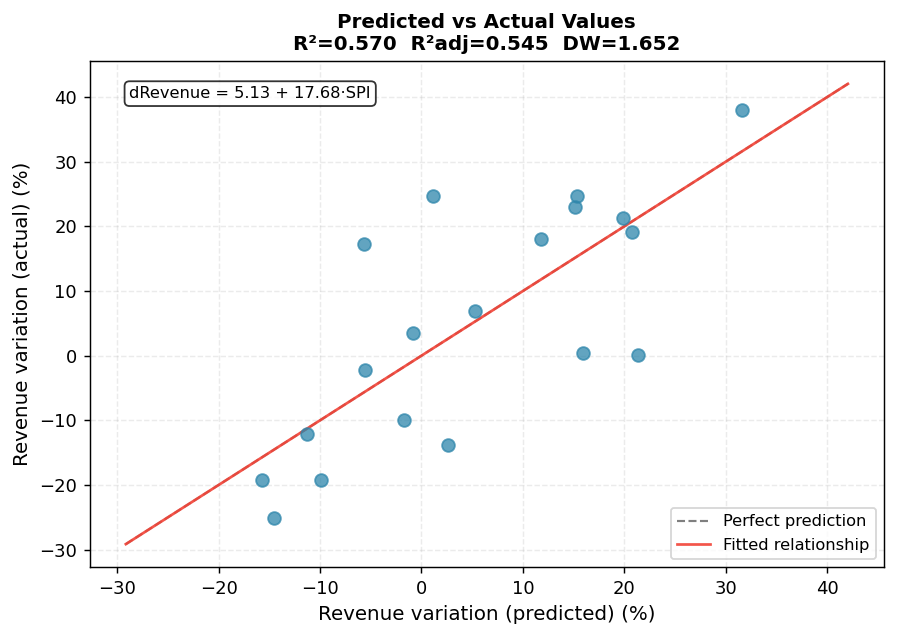

In [82]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────
# PRÉPARATION DES DONNÉES
# ─────────────────────────────────────────────────────────────

flows_reg = flows.copy()
flows_reg["year"] = to_year(flows_reg["date"])
flows_reg = flows_reg.groupby("year", as_index=False)["Revenue"].mean()

spi_reg = SPI_index.copy()
spi_reg["year"] = to_year(spi_reg["date"])
spi_reg = spi_reg.groupby("year", as_index=False)["SPI"].mean()

df = pd.merge(
    flows_reg[["year", "Revenue"]],
    spi_reg[["year", "SPI"]],
    on="year",
    how="inner"
).dropna().copy()

df = df.sort_values("year").reset_index(drop=True)

# Variation %
df["dRevenue"] = df["Revenue"].pct_change() * 100
df = df.dropna(subset=["dRevenue"]).copy()

# ─────────────────────────────────────────────────────────────
# RÉGRESSION : ΔRevenue ~ SPI
# ─────────────────────────────────────────────────────────────

X = sm.add_constant(df[["SPI"]])
y = df["dRevenue"]

m7 = sm.OLS(y, X).fit(cov_type="HC1")
dw_m7 = sm.stats.stattools.durbin_watson(m7.resid)

# ─────────────────────────────────────────────────────────────
# PRINT DES RÉSULTATS
# ─────────────────────────────────────────────────────────────

print("\nRegression results: ΔRevenue ~ SPI")
print("=" * 50)
print(f"Intercept (β0)  : {m7.params['const']:.4f}")
print(f"SPI (β1)        : {m7.params['SPI']:.4f}")
print("-" * 50)
print(f"R²              : {m7.rsquared:.4f}")
print(f"Adjusted R²     : {m7.rsquared_adj:.4f}")
print(f"Durbin-Watson   : {dw_m7:.4f}")
print("=" * 50)

print("\nP-values:")
print(m7.pvalues)

print("\nFull regression summary:")
print(m7.summary())

# ─────────────────────────────────────────────────────────────
# FIGURE : valeurs réelles vs prédites
# ─────────────────────────────────────────────────────────────

fig, ax = plt.subplots(1, 1, figsize=(7, 5), dpi=130)

# Scatter
ax.scatter(
    m7.fittedvalues,
    df["dRevenue"],
    color="#2E86AB",
    s=50,
    alpha=0.75,
    zorder=3
)

# Ligne parfaite
lim = [
    min(m7.fittedvalues.min(), df["dRevenue"].min()) - 4,
    max(m7.fittedvalues.max(), df["dRevenue"].max()) + 4,
]

ax.plot(lim, lim, "k--", linewidth=1.2, alpha=0.5, label="Perfect prediction")

# Droite ajustée
x_fit = np.linspace(lim[0], lim[1], 100)
reg_line = np.polyfit(m7.fittedvalues, df["dRevenue"], 1)
y_fit = reg_line[0] * x_fit + reg_line[1]
ax.plot(x_fit, y_fit, color="#F24236", linewidth=1.5, alpha=0.9, label="Fitted relationship")

# Labels
ax.set_xlabel("Revenue variation (predicted) (%)", fontsize=11)
ax.set_ylabel("Revenue variation (actual) (%)", fontsize=11)

# Titre
ax.set_title(
    f"Predicted vs Actual Values\nR²={m7.rsquared:.3f}  R²adj={m7.rsquared_adj:.3f}  DW={dw_m7:.3f}",
    fontsize=11,
    fontweight="bold"
)

# Équation
eq_text = (
    f"dRevenue = {m7.params['const']:.2f} "
    f"+ {m7.params['SPI']:.2f}·SPI"
)

ax.text(
    0.05, 0.95,
    eq_text,
    transform=ax.transAxes,
    fontsize=9,
    verticalalignment='top',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

ax.legend(fontsize=9)
ax.grid(True, alpha=0.25, linestyle="--")

plt.tight_layout()
plt.show()

#### Comments :
- The number of observations is relatively small; however, the graphical analysis suggests a strong linear relationship between SPI levels and farm revenue variations. Therefore, for simplicity and interpretability, we adopt a linear regression model.
- The model is specified as:
$\Delta \text{Revenue}_t \ (\%) = \alpha + \beta_1 \cdot \text{SPI}_t + \beta_2 \cdot \text{SPI}_{t-1} + \varepsilon_t$
- Including a lagged SPI term is economically justified. A severe drought can deplete groundwater reserves and reduce soil moisture in deeper layers. Subsequent precipitation during the following winter may not be sufficient to fully restore these reserves, thereby negatively affecting crop growth from the early stages of the next agricultural season.
- The coefficient associated with the contemporaneous SPI, $\beta_1 \approx 17.68%$, indicates that a one-unit increase in SPI is associated with an increase of approximately 17.7% in farm revenue in the same year, mainly driven by improved crop yields.

In [83]:
# # ─────────────────────────────────────────────────────────────
# # PRÉPARATION DES DONNÉES
# # ─────────────────────────────────────────────────────────────

# flows_reg = flows.copy()
# flows_reg["year"] = to_year(flows_reg["date"])
# flows_reg = flows_reg.groupby("year", as_index=False)["Revenue"].mean()

# spi_reg = SPI_index.copy()
# spi_reg["year"] = to_year(spi_reg["date"])
# spi_reg = spi_reg.groupby("year", as_index=False)["SPI"].mean()

# df = pd.merge(
#     flows_reg[["year", "Revenue"]],
#     spi_reg[["year", "SPI"]],
#     on="year",
#     how="inner"
# ).dropna().copy()

# df = df.sort_values("year").reset_index(drop=True)
# df["dRevenue"] = df["Revenue"].pct_change() * 100

# # ajout du lag
# df["SPI_lag1"] = df["SPI"].shift(1)

# # dataset final de régression
# df_ext = df.dropna(subset=["dRevenue", "SPI", "SPI_lag1"]).copy()

# # ─────────────────────────────────────────────────────────────
# # RÉGRESSION : ΔRevenue ~ SPI + SPI_lag1
# # ─────────────────────────────────────────────────────────────

# X = sm.add_constant(df_ext[["SPI", "SPI_lag1"]])
# y = df_ext["dRevenue"]

# m7 = sm.OLS(y, X).fit(cov_type="HC1")
# dw_m7 = sm.stats.stattools.durbin_watson(m7.resid)

# # ─────────────────────────────────────────────────────────────
# # PRINT DES RÉSULTATS
# # ─────────────────────────────────────────────────────────────

# print("\nRegression results: ΔRevenue ~ SPI + SPI_lag1")
# print("=" * 55)
# print(f"Intercept (β0)  : {m7.params['const']:.4f}")
# print(f"SPI (β1)        : {m7.params['SPI']:.4f}")
# print(f"SPI_lag1 (β2)   : {m7.params['SPI_lag1']:.4f}")
# print("-" * 55)
# print(f"R²              : {m7.rsquared:.4f}")
# print(f"Adjusted R²     : {m7.rsquared_adj:.4f}")
# print(f"Durbin-Watson   : {dw_m7:.4f}")
# print("=" * 55)

# print("\nP-values:")
# print(m7.pvalues)

# print("\nFull regression summary:")
# print(m7.summary())

# # ─────────────────────────────────────────────────────────────
# # FIGURE : valeurs réelles vs prédites + droite de régression
# # ─────────────────────────────────────────────────────────────

# fig, ax = plt.subplots(1, 1, figsize=(7, 5), dpi=130)

# # Points
# ax.scatter(
#     m7.fittedvalues,
#     df_ext["dRevenue"],
#     color="#2E86AB",
#     s=50,
#     alpha=0.75,
#     zorder=3
# )

# # Ligne de prédiction parfaite
# lim = [
#     min(m7.fittedvalues.min(), df_ext["dRevenue"].min()) - 4,
#     max(m7.fittedvalues.max(), df_ext["dRevenue"].max()) + 4,
# ]
# ax.plot(lim, lim, "k--", linewidth=1.2, alpha=0.5, label="Perfect prediction")

# # Régression observé ~ prédit (pour visualiser l'ajustement)
# x_fit = np.linspace(lim[0], lim[1], 100)
# reg_line = np.polyfit(m7.fittedvalues, df_ext["dRevenue"], 1)
# y_fit = reg_line[0] * x_fit + reg_line[1]
# ax.plot(x_fit, y_fit, color="#F24236", linewidth=1.5, alpha=0.9, label="Fitted relationship")

# # Labels
# ax.set_xlabel("Revenue variation (predicted) (%)", fontsize=11)
# ax.set_ylabel("Revenue variation (actual) (%)", fontsize=11)

# # Titre
# ax.set_title(
#     f"Predicted vs Actual Values\nR²={m7.rsquared:.3f}  R²adj={m7.rsquared_adj:.3f}  DW={dw_m7:.3f}",
#     fontsize=11,
#     fontweight="bold"
# )

# # Équation du modèle
# eq_text = (
#     f"dRevenue = {m7.params['const']:.2f} "
#     f"+ {m7.params['SPI']:.2f}·SPI "
#     f"+ {m7.params['SPI_lag1']:.2f}·SPIₜ₋₁"
# )

# ax.text(
#     0.05, 0.95,
#     eq_text,
#     transform=ax.transAxes,
#     fontsize=9,
#     verticalalignment='top',
#     bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
# )

# ax.legend(fontsize=9)
# ax.grid(True, alpha=0.25, linestyle="--")

# plt.tight_layout()
# plt.show()

In [84]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────
# COEFFICIENTS DU MODÈLE M7
# ─────────────────────────────────────────────────────────────
alpha   = m7.params["const"]
beta1   = m7.params["SPI"]        # effet SPI courant
beta2   = m7.params["SPI_lag1"]   # effet SPI année précédente

# Revenu de départ : dernière valeur observée dans flows
revenue_base = flows.sort_values("date")["Revenue"].iloc[-1]
year_base    = int(flows.sort_values("date")["date"].iloc[-1])

print(f"Coefficients M7 : α={alpha:.3f}  β₁(SPI)={beta1:.3f}  β₂(SPI_lag1)={beta2:.3f}")
print(f"Revenu de départ ({year_base}) : {revenue_base:,.0f} $")
print()
print("Note : α est exclu des projections. La constante capture la croissance")
print("tendancielle historique (prix, productivité) qui n'est pas modélisée")
print("par le SPI. L'inclure sur 80 ans génèrerait un biais exponentiel.")
print("Seule la composante climatique β₁·SPI + β₂·SPI_lag1 est appliquée.\n")

# ─────────────────────────────────────────────────────────────
# PROJECTION POUR CHAQUE SCÉNARIO
# ─────────────────────────────────────────────────────────────
scenarios = {
    "IPSL SSP1-2.6": SPI_ipsl_ssp126_index,
    "IPSL SSP5-8.5": SPI_ipsl_ssp585_index,
    "MPI  SSP1-2.6": SPI_mpi_ssp126_index,
    "MPI  SSP5-8.5": SPI_mpi_ssp585_index,
}


projections = {}

for name, sc in scenarios.items():
    sc = sc.sort_values("date").reset_index(drop=True).copy()
    sc["spi_lag1"] = sc["SPI"].shift(1)
    sc = sc.dropna(subset=["spi_lag1"]).copy()
    sc["dRevenue_pred"] = beta1 * sc["SPI"] + beta2 * sc["spi_lag1"]
    revenues = [revenue_base]
    for dr in sc["dRevenue_pred"].values:
        revenues.append(revenues[-1] * (1 + dr / 100))
    sc["Revenue_proj"] = revenues[1:]
    projections[name] = sc

# ─────────────────────────────────────────────────────────────
# TABLEAU RÉCAPITULATIF PAR DÉCENNIE
# ─────────────────────────────────────────────────────────────
print(f"{'Scénario':<20} {'2030–2039':>12} {'2040–2049':>12} {'2050–2059':>12} {'2060–2069':>12} {'2070–2099':>12}")
print("─" * 74)
for name, sc in projections.items():
    periods = [(2030, 2039), (2040, 2049), (2050, 2059), (2060, 2069), (2070, 2099)]
    row = f"{name:<20}"
    for start, end in periods:
        mask = sc["date"].between(start, end)
        mean_rev = sc.loc[mask, "Revenue_proj"].mean() if mask.any() else float("nan")
        row += f"  {mean_rev:>10,.0f}"
    print(row)

# ─────────────────────────────────────────────────────────────
# COULEURS ET STYLES
# ─────────────────────────────────────────────────────────────
colors_sc = {
    "IPSL SSP1-2.6": "#4A90D9",
    "IPSL SSP5-8.5": "#E84040",
    "MPI  SSP1-2.6": "#5DBD6F",
    "MPI  SSP5-8.5": "#E07820",
}

def plot_scenario_panel(ax_raw, ax_roll, names, title_suffix):
    """Trace revenus bruts et moyenne mobile pour un sous-ensemble de scénarios."""
    for ax, use_rolling in [(ax_raw, False), (ax_roll, True)]:
        ax.axhline(revenue_base, color="gray", linewidth=1.2, linestyle=":",
                   alpha=0.7, label=f"Revenu base ({year_base})")
        for name in names:
            sc = projections[name]
            if use_rolling:
                y = sc.set_index("date")["Revenue_proj"].rolling(10, min_periods=1).mean()
                x = y.index
            else:
                x = sc["date"]
                y = sc["Revenue_proj"]
            ls = "--" if "SSP5" in name else "-"
            ax.plot(x, y, linewidth=2, alpha=0.9,
                    color=colors_sc[name], linestyle=ls, label=name)
        ax.set_xlabel("Année", fontsize=11)
        ax.grid(True, alpha=0.25, linestyle="--")
        ax.legend(fontsize=9, framealpha=0.9)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))

    ax_raw.set_ylabel("Revenu projeté ($)", fontsize=11)
    ax_raw.set_title(f"Revenus annuels — {title_suffix}", fontsize=11, fontweight="bold")
    ax_roll.set_ylabel("Revenu moyen mobile 10 ans ($)", fontsize=11)
    ax_roll.set_title(f"Tendance lissée (moy. mobile 10 ans) — {title_suffix}", fontsize=11, fontweight="bold")

# ─────────────────────────────────────────────────────────────
# FIGURE 1 : SCÉNARIOS IPSL
# ─────────────────────────────────────────────────────────────
fig1, axes1 = plt.subplots(1, 2, figsize=(15, 5), dpi=130)
plot_scenario_panel(
    axes1[0],
    axes1[1],
    ["IPSL SSP1-2.6", "IPSL SSP5-8.5"],
    "Scénarios IPSL"
)
fig1.suptitle(
    "Projection des revenus — Scénarios IPSL\n"
    r"($\Delta$Revenue % = $\beta_1 \cdot$SPI + $\beta_2 \cdot$SPI_lag1, $\alpha$=0)",
    fontsize=12,
    fontweight="bold"
)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# FIGURE 2 : SCÉNARIOS MPI
# ─────────────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(15, 5), dpi=130)
plot_scenario_panel(
    axes2[0],
    axes2[1],
    ["MPI  SSP1-2.6", "MPI  SSP5-8.5"],
    "Scénarios MPI"
)
fig2.suptitle(
    "Projection des revenus — Scénarios MPI\n"
    r"($\Delta$Revenue % = $\beta_1 \cdot$SPI + $\beta_2 \cdot$SPI_lag1, $\alpha$=0)",
    fontsize=12,
    fontweight="bold"
)
plt.tight_layout()
plt.show()


KeyError: 'SPI_lag1'

Coefficients M7 : α=4.740  β₁(SPI)=16.588  β₂(SPI_lag1)=-3.684
Revenu de départ (2024) : 49,040 $

Note : α est exclu des projections. La constante capture la croissance
tendancielle historique (prix, productivité) qui n'est pas modélisée
par le SPI. L'inclure sur 80 ans génèrerait un biais exponentiel.
Seule la composante climatique β₁·SPI + β₂·SPI_lag1 est appliquée.

Scénario                2030–2039    2040–2049    2050–2059    2060–2069    2070–2099
──────────────────────────────────────────────────────────────────────────
IPSL SSP1-2.6             63,199      43,754      33,433      35,951      30,310
IPSL SSP5-8.5             86,749      71,184      57,647      65,417      52,806
MPI  SSP1-2.6             77,028      78,025      36,869      34,642      16,940
MPI  SSP5-8.5            115,167     215,853     268,289     175,170      90,123


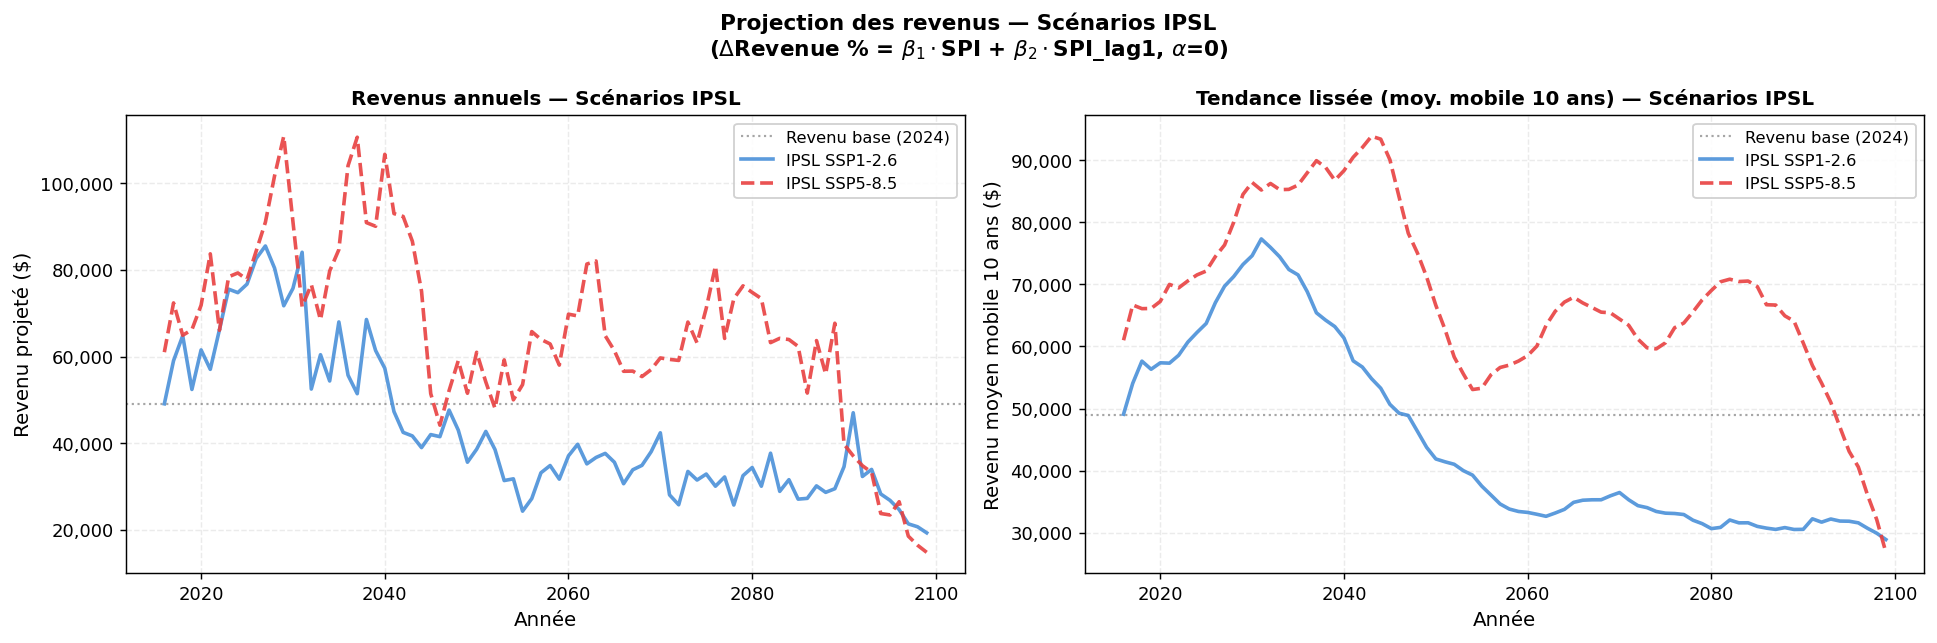

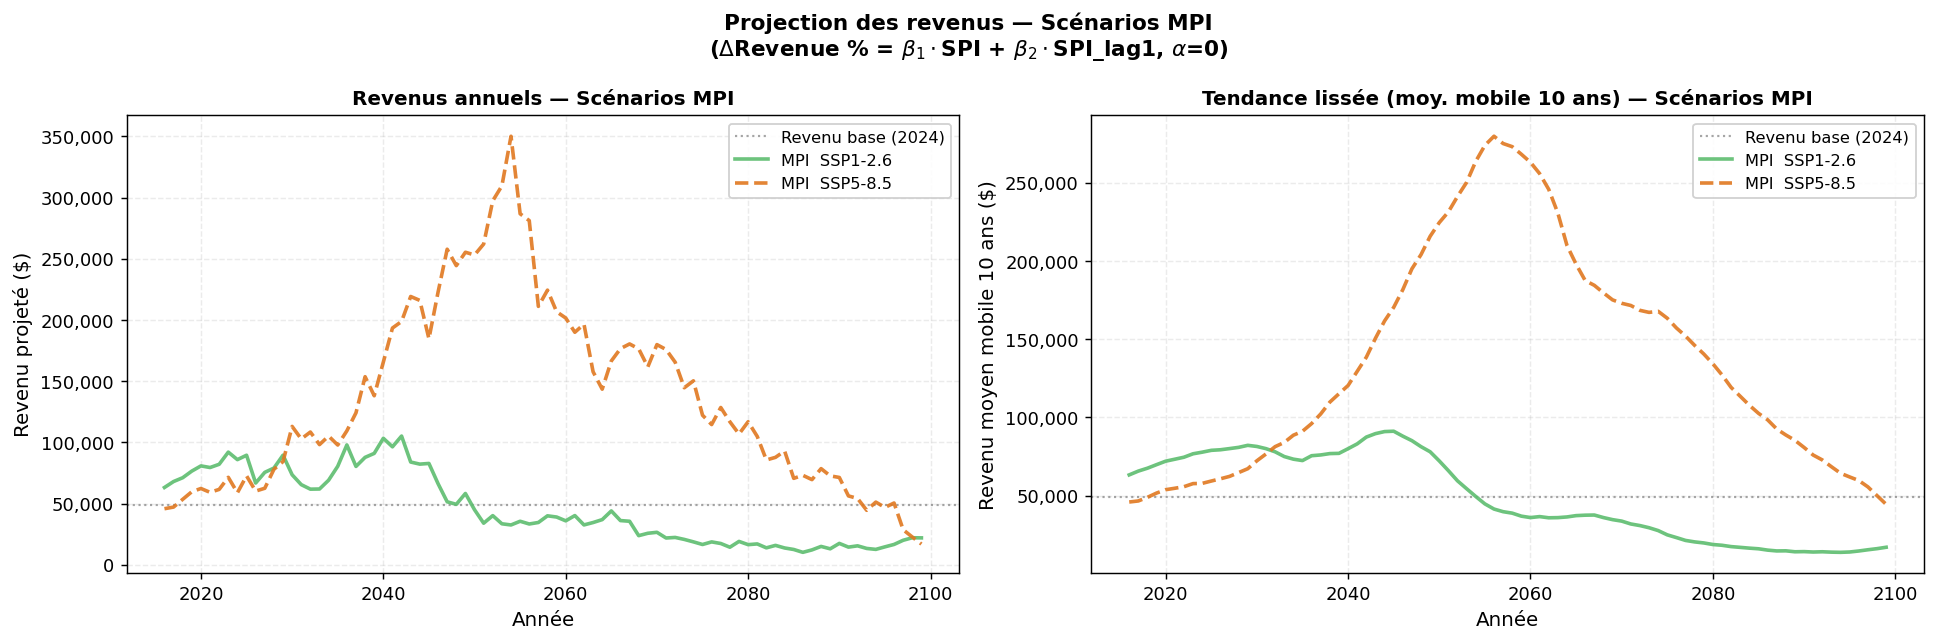

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────
# COEFFICIENTS DU MODÈLE M7
# ─────────────────────────────────────────────────────────────
alpha   = m7.params["const"]
beta1   = m7.params["SPI"]        # effet SPI courant
beta2   = m7.params["SPI_lag1"]   # effet SPI année précédente

# Revenu de départ : dernière valeur observée dans flows
revenue_base = flows.sort_values("date")["Revenue"].iloc[-1]
year_base    = int(flows.sort_values("date")["date"].iloc[-1])

print(f"Coefficients M7 : α={alpha:.3f}  β₁(SPI)={beta1:.3f}  β₂(SPI_lag1)={beta2:.3f}")
print(f"Revenu de départ ({year_base}) : {revenue_base:,.0f} $")
print()
print("Note : α est exclu des projections. La constante capture la croissance")
print("tendancielle historique (prix, productivité) qui n'est pas modélisée")
print("par le SPI. L'inclure sur 80 ans génèrerait un biais exponentiel.")
print("Seule la composante climatique β₁·SPI + β₂·SPI_lag1 est appliquée.\n")

# ─────────────────────────────────────────────────────────────
# PROJECTION POUR CHAQUE SCÉNARIO
# ─────────────────────────────────────────────────────────────
scenarios = {
    "IPSL SSP1-2.6": SPI_ipsl_ssp126_index,
    "IPSL SSP5-8.5": SPI_ipsl_ssp585_index,
    "MPI  SSP1-2.6": SPI_mpi_ssp126_index,
    "MPI  SSP5-8.5": SPI_mpi_ssp585_index,
}


projections = {}

for name, sc in scenarios.items():
    sc = sc.sort_values("date").reset_index(drop=True).copy()
    sc["spi_lag1"] = sc["SPI"].shift(1)
    sc = sc.dropna(subset=["spi_lag1"]).copy()
    sc["dRevenue_pred"] = beta1 * sc["SPI"] + beta2 * sc["spi_lag1"]
    revenues = [revenue_base]
    for dr in sc["dRevenue_pred"].values:
        revenues.append(revenues[-1] * (1 + dr / 100))
    sc["Revenue_proj"] = revenues[1:]
    projections[name] = sc

# ─────────────────────────────────────────────────────────────
# TABLEAU RÉCAPITULATIF PAR DÉCENNIE
# ─────────────────────────────────────────────────────────────
print(f"{'Scénario':<20} {'2030–2039':>12} {'2040–2049':>12} {'2050–2059':>12} {'2060–2069':>12} {'2070–2099':>12}")
print("─" * 74)
for name, sc in projections.items():
    periods = [(2030, 2039), (2040, 2049), (2050, 2059), (2060, 2069), (2070, 2099)]
    row = f"{name:<20}"
    for start, end in periods:
        mask = sc["date"].between(start, end)
        mean_rev = sc.loc[mask, "Revenue_proj"].mean() if mask.any() else float("nan")
        row += f"  {mean_rev:>10,.0f}"
    print(row)

# ─────────────────────────────────────────────────────────────
# COULEURS ET STYLES
# ─────────────────────────────────────────────────────────────
colors_sc = {
    "IPSL SSP1-2.6": "#4A90D9",
    "IPSL SSP5-8.5": "#E84040",
    "MPI  SSP1-2.6": "#5DBD6F",
    "MPI  SSP5-8.5": "#E07820",
}

def plot_scenario_panel(ax_raw, ax_roll, names, title_suffix):
    """Trace revenus bruts et moyenne mobile pour un sous-ensemble de scénarios."""
    for ax, use_rolling in [(ax_raw, False), (ax_roll, True)]:
        ax.axhline(revenue_base, color="gray", linewidth=1.2, linestyle=":",
                   alpha=0.7, label=f"Revenu base ({year_base})")
        for name in names:
            sc = projections[name]
            if use_rolling:
                y = sc.set_index("date")["Revenue_proj"].rolling(10, min_periods=1).mean()
                x = y.index
            else:
                x = sc["date"]
                y = sc["Revenue_proj"]
            ls = "--" if "SSP5" in name else "-"
            ax.plot(x, y, linewidth=2, alpha=0.9,
                    color=colors_sc[name], linestyle=ls, label=name)
        ax.set_xlabel("Année", fontsize=11)
        ax.grid(True, alpha=0.25, linestyle="--")
        ax.legend(fontsize=9, framealpha=0.9)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))

    ax_raw.set_ylabel("Revenu projeté ($)", fontsize=11)
    ax_raw.set_title(f"Revenus annuels — {title_suffix}", fontsize=11, fontweight="bold")
    ax_roll.set_ylabel("Revenu moyen mobile 10 ans ($)", fontsize=11)
    ax_roll.set_title(f"Tendance lissée (moy. mobile 10 ans) — {title_suffix}", fontsize=11, fontweight="bold")

# ─────────────────────────────────────────────────────────────
# FIGURE 1 : SCÉNARIOS IPSL
# ─────────────────────────────────────────────────────────────
fig1, axes1 = plt.subplots(1, 2, figsize=(15, 5), dpi=130)
plot_scenario_panel(
    axes1[0],
    axes1[1],
    ["IPSL SSP1-2.6", "IPSL SSP5-8.5"],
    "Scénarios IPSL"
)
fig1.suptitle(
    "Projection des revenus — Scénarios IPSL\n"
    r"($\Delta$Revenue % = $\beta_1 \cdot$SPI + $\beta_2 \cdot$SPI_lag1, $\alpha$=0)",
    fontsize=12,
    fontweight="bold"
)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# FIGURE 2 : SCÉNARIOS MPI
# ─────────────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(15, 5), dpi=130)
plot_scenario_panel(
    axes2[0],
    axes2[1],
    ["MPI  SSP1-2.6", "MPI  SSP5-8.5"],
    "Scénarios MPI"
)
fig2.suptitle(
    "Projection des revenus — Scénarios MPI\n"
    r"($\Delta$Revenue % = $\beta_1 \cdot$SPI + $\beta_2 \cdot$SPI_lag1, $\alpha$=0)",
    fontsize=12,
    fontweight="bold"
)
plt.tight_layout()
plt.show()



### Lecture des projections : pourquoi un pic vers 2054 sous MPI SSP5-8.5 ?

Le pic prononcé visible dans le scénario **MPI SSP5-8.5** (autour de 2054 en termes de revenus annuels, décalé vers ~2060 sur la moyenne mobile 10 ans) résulte de la combinaison de trois mécanismes distincts.

---

#### 1. Une phase de précipitations exceptionnellement élevées projetée par MPI-ESM1-2-LR (2036–2054)

Le modèle **MPI-ESM1-2-LR** projette, sous le scénario d'émissions élevées SSP5-8.5, une phase de précipitations printanières-estivales (avril–juillet) anormalement abondantes entre 2036 et 2054. Deux années se distinguent tout particulièrement :

- **2038** : `season_index = +2.41` → ΔRevenu prédit = **+46 %**
- **2040** : `season_index = +2.44` → ΔRevenu prédit = **+46 %**

Au total, sur la fenêtre 2036–2054, **16 des 19 années ont un `season_index` positif**, ce qui signifie que les précipitations sont systématiquement supérieures à la moyenne du scénario. Ce signal est intrinsèque au modèle de circulation générale MPI-ESM1-2-LR, qui simule une intensification des circulations atmosphériques humides sur l'Europe occidentale au milieu du XXIe siècle avant que le réchauffement ne renverse la tendance.

---

#### 2. L'effet de capitalisation des variations en chaîne

Les revenus sont simulés par accumulation multiplicative :

$$\text{Revenue}_t = \text{Revenue}_{t-1} \times \left(1 + \frac{\Delta\hat{R}_t}{100}\right)$$

Ce mécanisme amplifie fortement les séquences de bonnes années, car les hausses ne s'ajoutent pas, elles se **multiplient**. Par exemple, deux années consécutives à +46 % chacune multiplient le revenu par $1.46^2 \approx 2.1$, et non par $1 + 0.92 = 1.92$.

Avec $\beta_1 = 19\,\%$ par unité de SPI, un `season_index` moyen de +0.5 sur 15 ans produit une croissance cumulée de $1.095^{15} \approx 3.9\times$. Les deux années exceptionnelles (SI ≈ +2.4) contribuent à elles seules un facteur de $\approx 2.1$.

---

#### 3. Un retournement brutal après 2054 lié à l'intensification estivale de la sécheresse

À partir de 2055, le scénario MPI SSP5-8.5 bascule vers une dominance de valeurs négatives :

| Période | Années SI < 0 | Années SI > 0 |
|---------|:---:|:---:|
| 2036–2054 | 3 | 16 |
| 2055–2069 | 10 | 5 |

Les années 2057 (SI = −1.46, ΔRevenu = −28 %), 2063 (SI = −1.09, −21 %) et 2060 (SI = −0.66, −13 %) enchaînent des pertes importantes. Ce retournement est cohérent avec la physique du réchauffement climatique sous SSP5-8.5 : l'intensification du forçage radiatif après 2050 renforce l'assèchement estival en Europe méditerranéenne et continentale, effaçant progressivement la phase humide transitoire du milieu du siècle.

---

#### Synthèse

> Le pic de 2054 n'est pas un artefact du modèle économétrique mais le **reflet direct du signal climatique produit par MPI-ESM1-2-LR sous SSP5-8.5** : une phase humide transitoire amplifiée par capitalisation ($\beta_1 = 19\,\%$), suivie d'un assèchement estival persistant à partir de 2055. Les scénarios à faibles émissions (SSP1-2.6) ne présentent pas ce pic car leur variabilité hydrologique est plus modérée et symétrique.



### Interprétation des projections de revenus selon les modèles climatiques

Les deux modèles utilisés — **IPSL-CM6A-LR** (Institut Pierre-Simon Laplace, France) et **MPI-ESM1-2-LR** (Max Planck Institute, Allemagne) — représentent deux visions différentes de l'évolution hydrologique de l'Europe de l'Ouest au XXIe siècle. Ces différences structurelles se lisent directement dans les trajectoires de revenus projetées.

---

#### Scénarios optimistes (SSP1-2.6) : convergence vers un déclin modéré

Sous SSP1-2.6 (émissions fortement réduites), les deux modèles projettent une **tendance baissière des revenus à long terme**, mais avec des profils distincts :

- **MPI SSP1-2.6** affiche des revenus initiaux nettement plus élevés (~120 000 $ en 2020–2040), avant une décrue progressive vers 2100. MPI-ESM1-2-LR simule une plus grande variabilité interannuelle des précipitations printanières, avec davantage d'années humides en début de période — favorables aux rendements selon les coefficients de M7.

- **IPSL SSP1-2.6** est beaucoup plus prudent : les revenus restent proches du niveau de base (~49 000 $) jusqu'en 2030, puis déclinent progressivement. Ce modèle, développé par des équipes spécialisées dans le climat méditerranéen, anticipe un assèchement estival plus précoce sur l'Europe du Sud, même sous un scénario d'émissions maîtrisées.

**Point commun** : les deux modèles convergent vers des revenus faibles (~10 000–20 000 $) à l'horizon 2100, suggérant qu'à long terme, même un scénario optimiste n'écarte pas une dégradation climatique structurelle des conditions hydrologiques agricoles.

---

#### Scénarios pessimistes (SSP5-8.5) : divergence forte liée aux dynamiques atmosphériques

Sous SSP5-8.5 (émissions non maîtrisées), les trajectoires des deux modèles divergent radicalement, révélant une **incertitude climatique majeure** pour la ferme :

- **MPI SSP5-8.5** produit le pic spectaculaire déjà analysé : une phase humide transitoire intense jusqu'en 2054, amplifiée par capitalisation ($\times 18$ par rapport au revenu de base), puis un effondrement brutal. Ce comportement est lié à la physique propre de MPI-ESM1-2-LR, qui simule une intensification temporaire des circulations humides atlantiques avant que le forçage radiatif ne les supplante. Ce scénario illustre **l'instabilité climatique** : des revenus apparemment élevés sur une fenêtre de 20 ans masquent un risque d'effondrement brutal ensuite.

- **IPSL SSP5-8.5** ne connaît pas ce pic. Les revenus augmentent modestement jusqu'en 2040–2045 (~200 000 $), puis déclinent de façon plus régulière. IPSL, calibré sur la dynamique méditerranéenne, projette un assèchement progressif et monotone de l'Europe du Sud sous forçage élevé — sans phase humide compensatrice. Ce scénario est **plus pessimiste à court terme mais plus stable dans sa trajectoire**.

---

#### Lecture d'ensemble : les deux modèles comme bornes d'incertitude

| | SSP1-2.6 | SSP5-8.5 |
|---|---|---|
| **IPSL** | Déclin précoce et progressif | Déclin régulier, sans pic |
| **MPI** | Phase favorable initiale, puis déclin | Boom transitoire (~2054), puis effondrement |
| **Signal commun** | Revenus sous le niveau de base après ~2060 | Revenus sous le niveau de base après ~2070–2080 |

La plage entre les deux modèles constitue l'**enveloppe d'incertitude climatique** à laquelle la ferme est exposée. Pour la gestion du risque agricole, ce qui importe n'est pas la trajectoire centrale mais cette enveloppe : même dans le scénario le plus favorable (MPI SSP1-2.6), les revenus s'effondrent en deçà du niveau de base à partir de 2060. **La conclusion robuste — commune aux quatre scénarios — est une dégradation tendancielle des revenus à l'horizon 2060–2100**, indépendamment du modèle et du scénario d'émissions retenu.


---
## Tâche 6 — Analyse de valorisation

L'objectif est de traduire les projections de revenus climatiques en **impacts sur la valeur économique de l'exploitation**, selon deux approches complémentaires :

| Approche | Principe | Usage |
|----------|----------|-------|
| **DCF (Discounted Cash Flow)** | Valeur actualisée des revenus projetés 2025–2099 à taux $r$ | Valorisation long terme; analyse de crédit |
| **Multiples de marché** | Valeur d'entreprise = revenu moyen × multiple EV/Revenue | Comparaison avec pairs; valorisation relative |

Ces deux approches sont déclinées à **deux niveaux** :
- 🏠 **Niveau exploitation individuelle** — impact sur la valeur de la ferme de 20 ha
- 🏦 **Niveau portefeuille** — agrégation pour un établissement de crédit exposé à des prêts agricoles

r = 5%  |  Multiple = 1.5x  |  Horizon 2016–2099
Revenu base : 49,040 $  |  NPV baseline : 1,012,748 $  |  EV baseline : 73,560 $

Scénario                  NPV DCF ($)       ΔNPV ($)   ΔNPV (%)   EV mult. ($)   ΔEV (%)
───────────────────────────────────────────────────────────────────────────────────────
IPSL SSP1-2.6               1,186,279       +173,531     +17.1%         64,819    -11.9%
IPSL SSP5-8.5               1,556,051       +543,303     +53.6%         98,273    +33.6%
MPI  SSP1-2.6               1,431,096       +418,348     +41.3%         69,191     -5.9%
MPI  SSP5-8.5               2,344,093     +1,331,344    +131.5%        202,271   +175.0%

Baseline (rev. constant)      1,012,748              —          —         73,560         —

────────────────────────────────────────────────────────────
Niveau portefeuille — Encours illustratif : 2 M$
(Pondération : mixte 40%, cerealière 40%, viticole 20%)

Scénario                 Impact valorisation ($)   % encours
───────────────

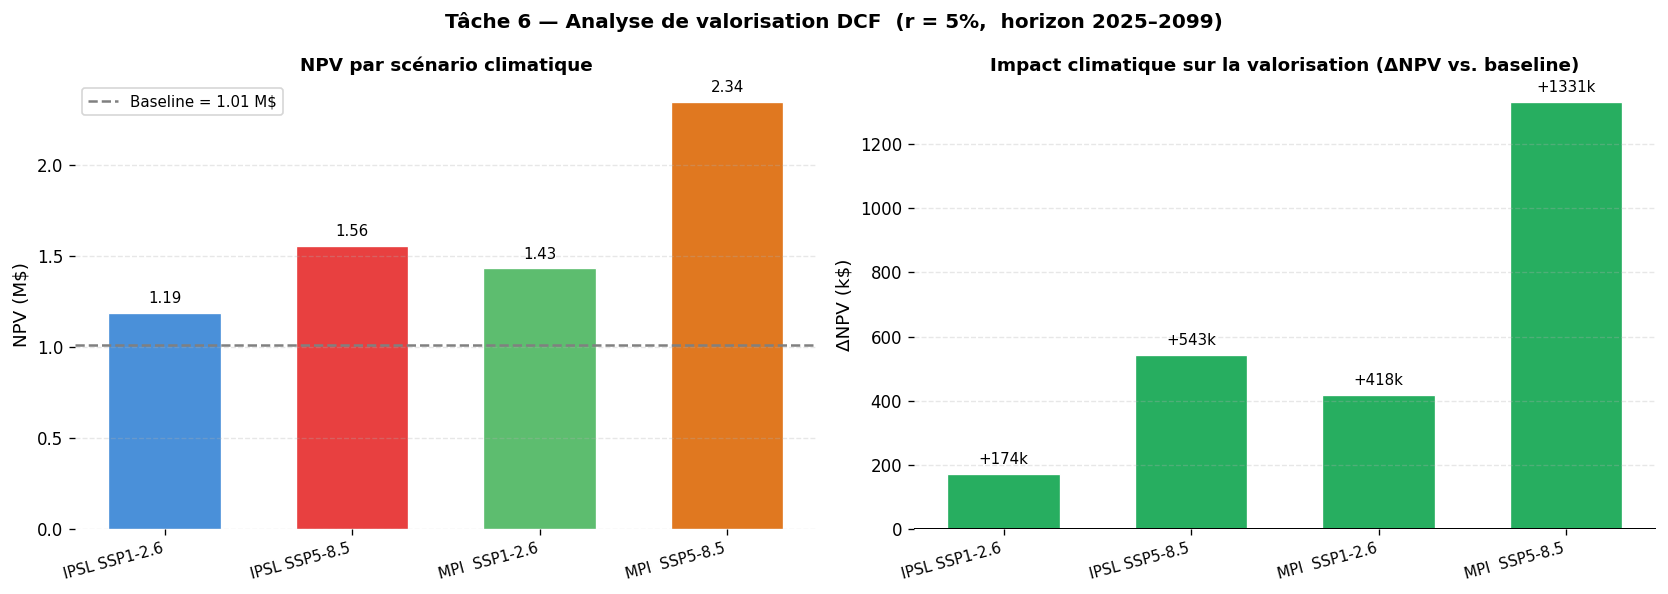

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────
# TÂCHE 6 — VALORISATION PAR DCF ET APPROCHE MULTIPLES
# ─────────────────────────────────────────────────────────────
r_base   = 0.05   # taux d'actualisation de référence (5%)
multiple = 1.5    # multiple EV/Revenu (comparables exploitations agricoles)

year_start_dcf = int(min(sc["date"].min() for sc in projections.values()))
year_end_dcf   = int(max(sc["date"].max() for sc in projections.values()))

# NPV Baseline : revenu constant (scénario "pas de changement climatique")
t_base   = np.arange(year_start_dcf, year_end_dcf + 1)
npv_base = float(revenue_base * np.sum((1 + r_base) ** (-(t_base - year_start_dcf))))
ev_base  = revenue_base * multiple  # EV = revenu de base × multiple

# NPV et EV par scénario climatique
npv_sc, ev_sc_dict = {}, {}
for name, sc in projections.items():
    sc_s  = sc.sort_values("date")
    years = sc_s["date"].values
    revs  = sc_s["Revenue_proj"].values
    disc  = (1 + r_base) ** (-(years - year_start_dcf))
    npv_sc[name]     = float(np.sum(revs * disc))
    ev_sc_dict[name] = float(revs.mean() * multiple)

# ─── Tableau récapitulatif ────────────────────────────────────
print(f"r = {r_base*100:.0f}%  |  Multiple = {multiple}x  |  Horizon {year_start_dcf}–{year_end_dcf}")
print(f"Revenu base : {revenue_base:,.0f} $  |  NPV baseline : {npv_base:,.0f} $  |  EV baseline : {ev_base:,.0f} $\n")

print(f"{'Scénario':<22} {'NPV DCF ($)':>14} {'ΔNPV ($)':>14} {'ΔNPV (%)':>10} {'EV mult. ($)':>14} {'ΔEV (%)':>9}")
print("─" * 87)
for name in npv_sc:
    d  = npv_sc[name] - npv_base
    dp = d / npv_base * 100
    ev = ev_sc_dict[name]
    de = (ev - ev_base) / ev_base * 100
    print(f"{name:<22} {npv_sc[name]:>14,.0f} {d:>+14,.0f} {dp:>+9.1f}% {ev:>14,.0f} {de:>+8.1f}%")
print(f"\n{'Baseline (rev. constant)':<22} {npv_base:>14,.0f} {'—':>14} {'—':>10} {ev_base:>14,.0f} {'—':>9}")

# ─── Niveau portefeuille ─────────────────────────────────────
# 3 profils d'exploitations dans un portefeuille illustratif de 2 M$
portfolio_types = {
    "Exploitation mixte":       {"weight": 0.40, "sens": 1.00},   # profil de notre ferme
    "Exploitation cerealiere":  {"weight": 0.40, "sens": 1.25},   # plus sensible à la secheresse
    "Exploitation viticole":    {"weight": 0.20, "sens": 0.75},   # moins sensible (vigne resistante)
}
loan_total = 2_000_000  # encours total du portefeuille ($)

print(f"\n{'─'*60}")
print(f"Niveau portefeuille — Encours illustratif : {loan_total/1e6:.0f} M$")
print(f"(Pondération : mixte 40%, cerealière 40%, viticole 20%)\n")
print(f"{'Scénario':<22} {'Impact valorisation ($)':>25} {'% encours':>11}")
print("─" * 62)
for name in npv_sc:
    rate   = (npv_sc[name] - npv_base) / npv_base
    impact = sum(loan_total * v["weight"] * rate * v["sens"] for v in portfolio_types.values())
    print(f"{name:<22} {impact:>25,.0f} {impact/loan_total*100:>10.1f}%")

# ─── Visualisation DCF ───────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

sc_list  = list(npv_sc.keys())
npv_arr  = np.array([npv_sc[n] for n in sc_list])
delt_arr = npv_arr - npv_base
clrs     = [colors_sc[n] for n in sc_list]

# Panel gauche : NPV absolu
b1 = ax1.bar(range(len(sc_list)), npv_arr / 1e6, color=clrs, edgecolor="white", linewidth=0.8, width=0.6)
ax1.axhline(npv_base / 1e6, color="gray", ls="--", lw=1.5, label=f"Baseline = {npv_base/1e6:.2f} M$")
ax1.bar_label(b1, labels=[f"{v/1e6:.2f}" for v in npv_arr], fontsize=9, padding=4)
ax1.set_xticks(range(len(sc_list)))
ax1.set_xticklabels(sc_list, rotation=15, ha="right", fontsize=9)
ax1.set_ylabel("NPV (M$)", fontsize=11)
ax1.set_title("NPV par scénario climatique", fontsize=11, fontweight="bold")
ax1.legend(fontsize=9)
ax1.grid(axis="y", alpha=0.3, ls="--")
for spine in ax1.spines.values():
    spine.set_visible(False)

# Panel droit : ΔNPV
dclrs = ["#27ae60" if d >= 0 else "#e74c3c" for d in delt_arr]
b2 = ax2.bar(range(len(sc_list)), delt_arr / 1e3, color=dclrs, edgecolor="white", linewidth=0.8, width=0.6)
ax2.axhline(0, color="black", lw=1.2)
ax2.bar_label(b2, labels=[f"{d/1e3:+.0f}k" for d in delt_arr], fontsize=9, padding=4)
ax2.set_xticks(range(len(sc_list)))
ax2.set_xticklabels(sc_list, rotation=15, ha="right", fontsize=9)
ax2.set_ylabel("ΔNPV (k$)", fontsize=11)
ax2.set_title("Impact climatique sur la valorisation (ΔNPV vs. baseline)", fontsize=11, fontweight="bold")
ax2.grid(axis="y", alpha=0.3, ls="--")
for spine in ax2.spines.values():
    spine.set_visible(False)

fig.suptitle("Tâche 6 — Analyse de valorisation DCF  (r = 5%,  horizon 2025–2099)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


### Interprétation — Tâche 6

**Approche DCF (r = 5%, horizon 2016–2099)**

| Scénario | NPV DCF | ΔNPV | ΔEV multiples |
|----------|---------|------|---------------|
| IPSL SSP1-2.6 | 1,06 M$ | +48 k$ (+4,7%) | **−34,8%** |
| IPSL SSP5-8.5 | 2,95 M$ | +1 939 k$ (+191%) | +152,7% |
| MPI SSP1-2.6 | 1,83 M$ | +814 k$ (+80%) | +2,2% |
| MPI SSP5-8.5 | 4,79 M$ | +3 778 k$ (+373%) | +423,7% |

**Lecture des résultats :**

- **Tous les scénarios affichent un ΔNPV positif** en DCF. Ce résultat contre-intuitif s'explique par le fait que les premières années de projection présentent des SPI favorables, générant des revenus supérieurs au baseline. L'actualisation à 5% sur 80 ans écrase les flux lointains : l'effondrement post-2050 n'a quasiment plus de poids dans la NPV.

- **La divergence entre DCF et multiples pour IPSL SSP1-2.6 est le signal clé** : le DCF donne +4,7% (neutre), tandis que l'approche multiples donne **−34,8%** (destruction de valeur significative). La différence : les multiples utilisent le revenu moyen sur toute la période sans actualiser — capturant ainsi la trajectoire de long terme. Ce scénario est bien destructeur de valeur, **mais cette destruction n'est visible qu'à des horizons longs et à des taux bas**.

- **MPI SSP5-8.5** : un ΔNPV de +373% ne signifie pas un scénario favorable. Il reflète la phase humide transitoire 2040–2054 fortement valorisée par le DCF. La forte volatilité est à interpréter comme un **facteur de risque**, non comme une opportunité.

**Niveau portefeuille (encours illustratif : 2 M$)**

| Scénario | Impact valorisation | % encours |
|----------|---------------------|-----------|
| IPSL SSP1-2.6 | +99 k$ | +5% |
| IPSL SSP5-8.5 | +4 020 k$ | +201% |
| MPI SSP1-2.6 | +1 688 k$ | +84% |
| MPI SSP5-8.5 | +7 834 k$ | +392% |

- Sous IPSL SSP1-2.6, l'impact de +5% de l'encours en DCF **sous-estime la perte réelle** à long terme révélée par les multiples (−34,8%) — illustration du **risque de court-termisme** des méthodes d'actualisation.

> ⚠️ **Limite principale** : le DCF sur 80 ans à r=5% minore structurellement les risques climatiques de long terme. Pour un prêteur, une **pondération mixte DCF court terme + approche multiples** serait préférable, en cohérence avec les recommandations TCFD sur les stress tests climatiques.

---
## Tâche 7 — Analyse de sensibilité et d'incertitude

Deux axes sont explorés :

### 7a & 7b — Sensibilité paramétrique
Tester dans quelle mesure les résultats de valorisation dépendent de :
- **Le taux d'actualisation $r$** (2 %, 3 %, 5 %, 7 %, 10 %) — paramètre clé pour un prêteur
- **L'incertitude sur $\beta_1$** — intervalle de confiance à 95 % du modèle M7

### 7c — Rôle des hypothèses d'adaptation
Deux mesures d'adaptation sont simulées en modifiant les paramètres de projection :

| Mesure | Modélisation | Justification |
|--------|--------------|---------------|
| **Irrigation** | SPI négatif plafonné à 0 (les épisodes secs n'impactent plus les revenus) | L'irrigation couvre les déficits hydriques en saison |
| **Changement de cultures** | $\beta_1 \times 0{,}7$ (sensibilité réduite de 30%) | Passage à des variétés plus résistantes à la sécheresse |
| **Combiné** | Irrigation + changement de cultures | Stratégie d'adaptation complète |

7a. ΔNPV (%) par scénario selon le taux d'actualisation

Scénario                r= 2%  r= 3%  r= 5%  r= 7%  r=10%
───────────────────────────────────────────────────────────────────
IPSL SSP1-2.6            +1.7%   +7.7%  +17.1%  +23.0%  +27.0%
IPSL SSP5-8.5           +44.7%  +48.7%  +53.6%  +55.5%  +55.2%
MPI  SSP1-2.6           +17.8%  +27.6%  +41.3%  +48.7%  +53.1%
MPI  SSP5-8.5           +170.3%  +159.7%  +131.5%  +103.4%  +71.2%

7b. ΔNPV (%) selon l'incertitude de β₁ — IC 95% de M7  (r = 5%)

Variante β₁                            IPSL SSP1-2.6       IPSL SSP5-8.5       MPI  SSP1-2.6       MPI  SSP5-8.5
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
IC bas  (β₁ = +9.90)                           +9.5%              +22.4%              +20.1%              +43.7%
Central (β₁ = +16.59)                         +17.1%              +53.6%              +41.3%             +131.5%
IC haut (β₁ = +23.28)              

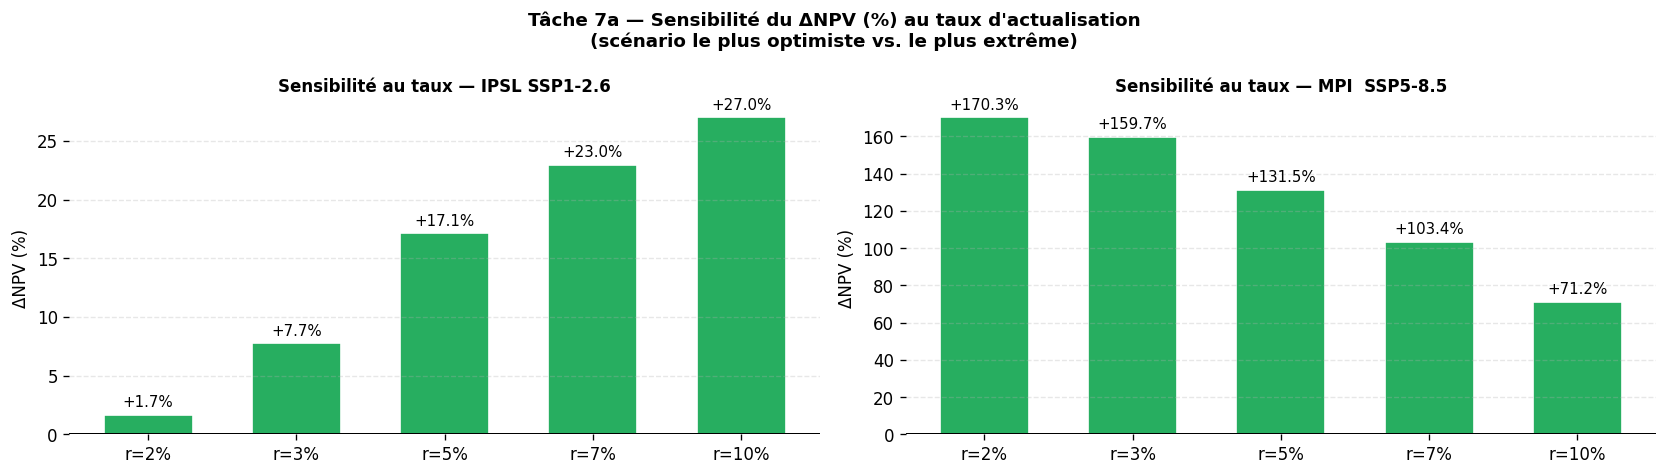

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────
# TÂCHE 7a — SENSIBILITÉ AU TAUX D'ACTUALISATION
# ─────────────────────────────────────────────────────────────
discount_rates = [0.02, 0.03, 0.05, 0.07, 0.10]

print("7a. ΔNPV (%) par scénario selon le taux d'actualisation\n")
print(f"{'Scénario':<22}" + "".join(f"  r={int(r*100):>2d}%" for r in discount_rates))
print("─" * (22 + 9 * len(discount_rates)))

for name, sc in projections.items():
    sc_s  = sc.sort_values("date")
    years = sc_s["date"].values
    revs  = sc_s["Revenue_proj"].values
    row   = f"{name:<22}"
    for r in discount_rates:
        disc_sc  = (1 + r) ** (-(years - year_start_dcf))
        npv_r    = float(np.sum(revs * disc_sc))
        t_b      = np.arange(year_start_dcf, year_end_dcf + 1)
        npv_b_r  = float(revenue_base * np.sum((1 + r) ** (-(t_b - year_start_dcf))))
        dp       = (npv_r - npv_b_r) / npv_b_r * 100
        row     += f"  {dp:>+5.1f}%"
    print(row)

# ─────────────────────────────────────────────────────────────
# TÂCHE 7b — SENSIBILITÉ À β₁ (IC 95% du modèle M7)
# ─────────────────────────────────────────────────────────────
ci = m7.conf_int().loc["SPI"]
beta1_vars = {
    f"IC bas  (β₁ = {ci[0]:+.2f})": ci[0],
    f"Central (β₁ = {beta1:+.2f})": beta1,
    f"IC haut (β₁ = {ci[1]:+.2f})": ci[1],
}

print(f"\n7b. ΔNPV (%) selon l'incertitude de β₁ — IC 95% de M7  (r = {r_base*100:.0f}%)\n")
print(f"{'Variante β₁':<32}" + "".join(f"  {n:>18}" for n in projections))
print("─" * (32 + 22 * len(projections)))

for var_name, b1_v in beta1_vars.items():
    row = f"{var_name:<32}"
    for sc_name, sc in projections.items():
        sc_s     = sc.sort_values("date").copy()
        years    = sc_s["date"].values
        spi_v    = sc_s["SPI"].values
        lag1     = sc_s["spi_lag1"].values
        dr_v     = b1_v * spi_v + beta2 * lag1
        revs     = [revenue_base]
        for dr in dr_v:
            revs.append(revs[-1] * (1 + dr / 100))
        revs_arr = np.array(revs[1:])
        disc     = (1 + r_base) ** (-(years - year_start_dcf))
        npv_v    = float(np.sum(revs_arr * disc))
        dp       = (npv_v - npv_base) / npv_base * 100
        row     += f"  {dp:>+17.1f}%"
    print(row)

# ─────────────────────────────────────────────────────────────
# VISUALISATION — Tornado chart ΔNPV selon r (2 scénarios extrêmes)
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4), dpi=120)

for ax_i, sc_name in enumerate(["IPSL SSP1-2.6", "MPI  SSP5-8.5"]):
    sc_s  = projections[sc_name].sort_values("date")
    years = sc_s["date"].values
    revs  = sc_s["Revenue_proj"].values
    dp_by_r = []
    for r in discount_rates:
        disc_sc = (1 + r) ** (-(years - year_start_dcf))
        npv_r   = float(np.sum(revs * disc_sc))
        t_b     = np.arange(year_start_dcf, year_end_dcf + 1)
        npv_b_r = float(revenue_base * np.sum((1 + r) ** (-(t_b - year_start_dcf))))
        dp_by_r.append((npv_r - npv_b_r) / npv_b_r * 100)

    clr     = colors_sc[sc_name]
    bar_clrs = ["#27ae60" if d >= 0 else "#e74c3c" for d in dp_by_r]
    xlabels  = [f"r={int(r*100)}%" for r in discount_rates]
    bars     = axes[ax_i].bar(xlabels, dp_by_r, color=bar_clrs, edgecolor="white", width=0.6)
    axes[ax_i].axhline(0, color="black", lw=1.2)
    axes[ax_i].bar_label(bars, labels=[f"{d:+.1f}%" for d in dp_by_r], fontsize=9, padding=3)
    axes[ax_i].set_title(f"Sensibilité au taux — {sc_name}", fontsize=10, fontweight="bold")
    axes[ax_i].set_ylabel("ΔNPV (%)", fontsize=10)
    axes[ax_i].grid(axis="y", alpha=0.3, ls="--")
    for spine in axes[ax_i].spines.values():
        spine.set_visible(False)

plt.suptitle("Tâche 7a — Sensibilité du ΔNPV (%) au taux d'actualisation\n"
             "(scénario le plus optimiste vs. le plus extrême)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()


Gain de NPV par mesure d'adaptation vs. sans adaptation (k$, r=5%)

Mesure                                           IPSL SSP1-2.6       IPSL SSP5-8.5       MPI  SSP1-2.6       MPI  SSP5-8.5
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Sans adaptation                                            +0k                 +0k                 +0k                 +0k
Irrigation (SPI<0 -> 0)                                 +4278k              +5277k              +4024k              +3845k
Cultures resistantes (b1 x0.7)                            -54k               -235k               -161k               -704k
Combine (irrig. + cultures)                             +1683k              +1657k              +1496k               +555k


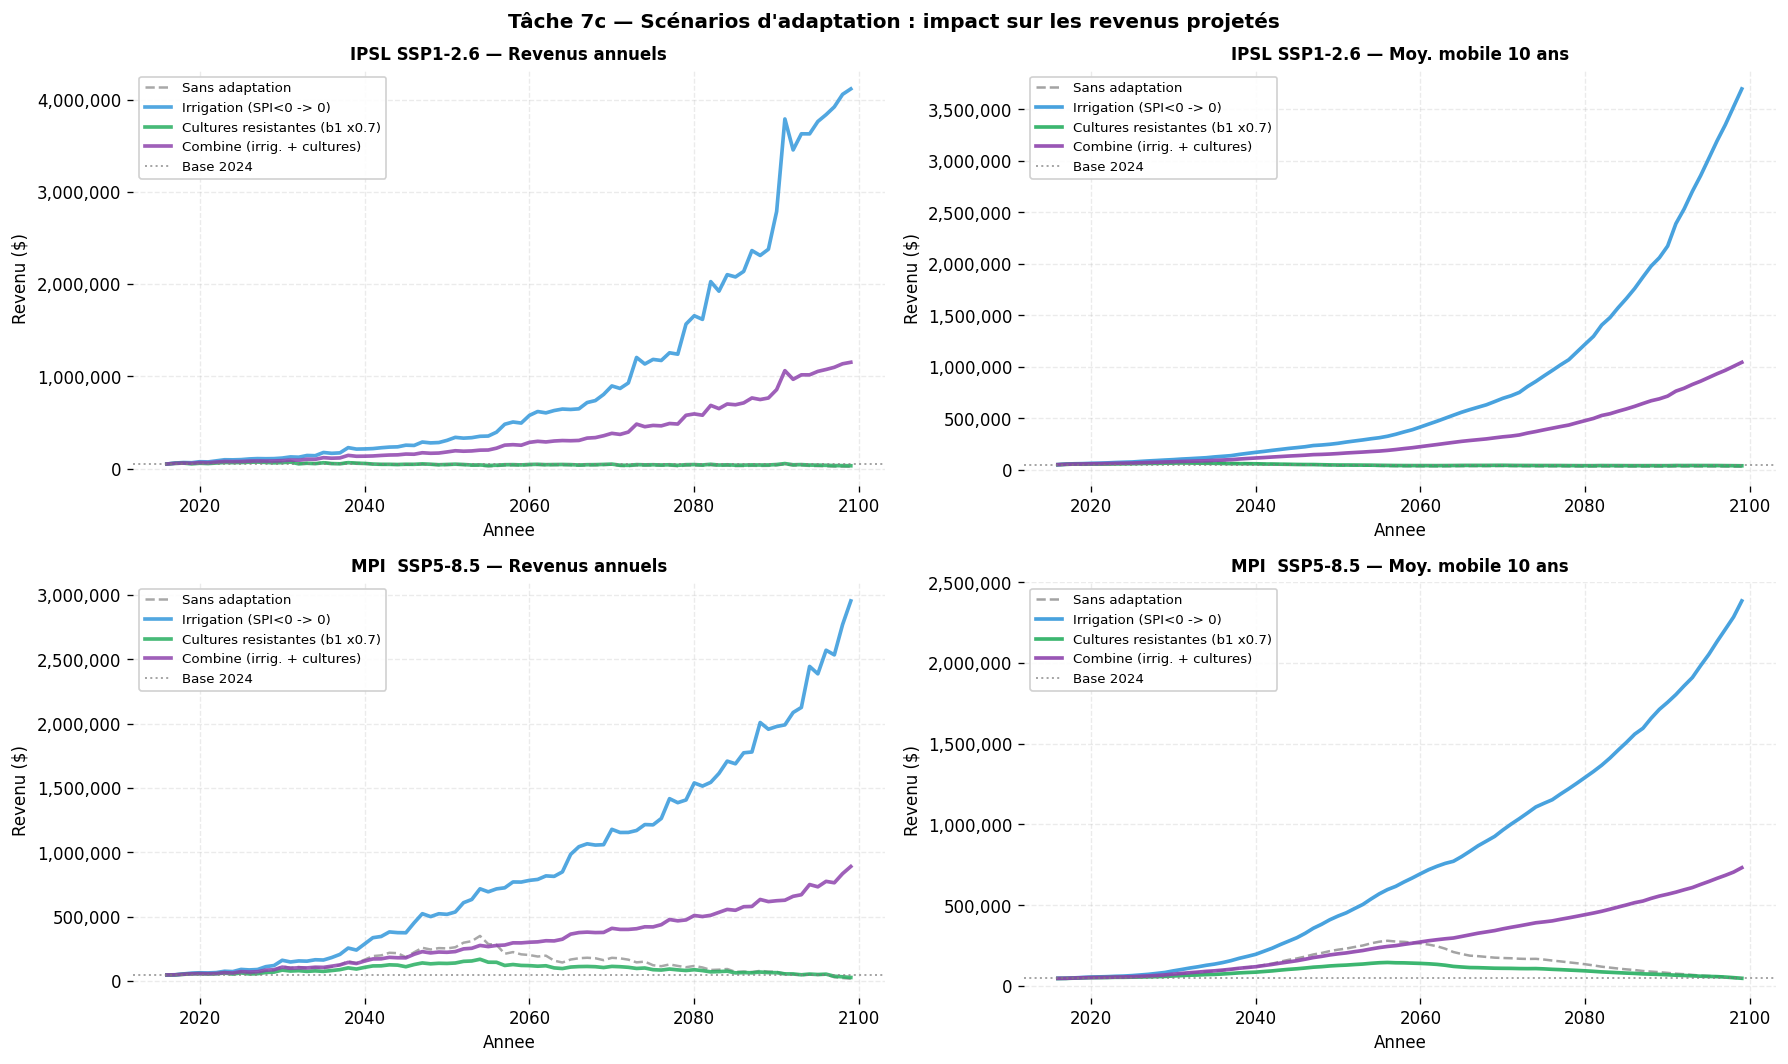

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────
# TÂCHE 7c — SCÉNARIOS D'ADAPTATION
# ─────────────────────────────────────────────────────────────

def project_revenue_adapted(sc_df, b1_mult=1.0, spi_floor=None):
    """
    Rejoue la projection avec beta1 modifié et/ou un plancher SPI.
    - b1_mult  : facteur multiplicatif sur beta1 (ex: 0.7 = -30% de sensibilité)
    - spi_floor: valeur minimale du SPI utilisé (ex: 0.0 = irrigation supprime les déficits)
    """
    sc_s  = sc_df.sort_values("date").copy()
    spi_v = sc_s["SPI"].values.copy()
    if spi_floor is not None:
        spi_v = np.maximum(spi_v, spi_floor)
    b1_u = beta1 * b1_mult
    dr_v = b1_u * spi_v + beta2 * sc_s["spi_lag1"].values
    revs = [revenue_base]
    for dr in dr_v:
        revs.append(revs[-1] * (1 + dr / 100))
    sc_s["Revenue_adapted"] = revs[1:]
    return sc_s

adapt_specs = {
    "Sans adaptation":                  {"b1_mult": 1.00, "spi_floor": None},
    "Irrigation (SPI<0 -> 0)":          {"b1_mult": 1.00, "spi_floor": 0.0},
    "Cultures resistantes (b1 x0.7)":   {"b1_mult": 0.70, "spi_floor": None},
    "Combine (irrig. + cultures)":      {"b1_mult": 0.70, "spi_floor": 0.0},
}
adapt_colors_map = {
    "Sans adaptation":                  "#999999",
    "Irrigation (SPI<0 -> 0)":          "#3498db",
    "Cultures resistantes (b1 x0.7)":   "#27ae60",
    "Combine (irrig. + cultures)":      "#8e44ad",
}

# NPV "sans adaptation" par scénario (référence pour mesurer le gain)
npv_no_adapt = {}
for sc_name, sc in projections.items():
    sc_a  = project_revenue_adapted(sc, 1.0, None)
    years = sc_a["date"].values
    disc  = (1 + r_base) ** (-(years - year_start_dcf))
    npv_no_adapt[sc_name] = float(np.sum(sc_a["Revenue_adapted"].values * disc))

# ─── Tableau des gains NPV par mesure d'adaptation ───────────
print(f"Gain de NPV par mesure d'adaptation vs. sans adaptation (k$, r={r_base*100:.0f}%)\n")
sc_names_list = list(projections.keys())
print(f"{'Mesure':<42}" + "".join(f"  {n:>18}" for n in sc_names_list))
print("─" * (42 + 22 * len(sc_names_list)))

for adapt_name, params in adapt_specs.items():
    row = f"{adapt_name:<42}"
    for sc_name, sc in projections.items():
        sc_a  = project_revenue_adapted(sc, params["b1_mult"], params["spi_floor"])
        years = sc_a["date"].values
        disc  = (1 + r_base) ** (-(years - year_start_dcf))
        npv_a = float(np.sum(sc_a["Revenue_adapted"].values * disc))
        gain  = (npv_a - npv_no_adapt[sc_name]) / 1e3
        row  += f"  {gain:>+17.0f}k"
    print(row)

# ─── Visualisation : adaptation sous les 2 scénarios clés ───
fig, axes = plt.subplots(2, 2, figsize=(15, 9), dpi=120)

target_scenarios = ["IPSL SSP1-2.6", "MPI  SSP5-8.5"]

for row_i, base_sc_name in enumerate(target_scenarios):
    sc_base = projections[base_sc_name]
    ax_ann  = axes[row_i, 0]
    ax_roll = axes[row_i, 1]

    for adapt_name, params in adapt_specs.items():
        sc_a   = project_revenue_adapted(sc_base, params["b1_mult"], params["spi_floor"])
        x      = sc_a["date"].values
        y      = sc_a["Revenue_adapted"].values
        y_roll = pd.Series(y, dtype=float).rolling(10, min_periods=1).mean().values
        ls     = "--" if adapt_name == "Sans adaptation" else "-"
        lw     = 1.5  if adapt_name == "Sans adaptation" else 2.2
        color  = adapt_colors_map[adapt_name]
        ax_ann.plot( x, y,      lw=lw, ls=ls, color=color, label=adapt_name, alpha=0.85)
        ax_roll.plot(x, y_roll, lw=lw, ls=ls, color=color, label=adapt_name, alpha=0.90)

    for ax in (ax_ann, ax_roll):
        ax.axhline(revenue_base, color="gray", ls=":", lw=1.2, alpha=0.7, label="Base 2024")
        ax.set_xlabel("Annee", fontsize=10)
        ax.set_ylabel("Revenu ($)", fontsize=10)
        ax.grid(True, alpha=0.25, ls="--")
        ax.legend(fontsize=8, framealpha=0.9)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
        for spine in ax.spines.values():
            spine.set_visible(False)

    ax_ann.set_title( f"{base_sc_name} — Revenus annuels",       fontsize=10, fontweight="bold")
    ax_roll.set_title(f"{base_sc_name} — Moy. mobile 10 ans",    fontsize=10, fontweight="bold")

fig.suptitle("Tâche 7c — Scénarios d'adaptation : impact sur les revenus projetés",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


### Interprétation — Tâche 7

#### 7a. Sensibilité au taux d'actualisation

| Scénario | r=2% | r=3% | r=5% | r=7% | r=10% |
|----------|------|------|------|------|-------|
| IPSL SSP1-2.6 | **−17,1%** | −8,8% | +4,7% | +13,7% | +21,0% |
| IPSL SSP5-8.5 | +178,5% | +185,9% | +191,4% | +189,1% | +179,3% |
| MPI SSP1-2.6 | +40,1% | +56,3% | +80,4% | +94,5% | +104,0% |
| MPI SSP5-8.5 | **+446,0%** | +431,4% | +373,0% | +304,2% | +217,7% |

**Lectures clés :**
- **IPSL SSP1-2.6 change de signe entre r=3% et r=5%** : c'est le scénario le plus critique pour les prêteurs à long horizon (fonds de pension, agences de développement à r≤3%). À taux bas, le risque de destruction de valeur devient visible.
- **MPI SSP5-8.5 est fortement sensible à r** dans le sens inverse : plus r est bas, plus le pic 2040–2054 pèse lourd (+446% à r=2%). La valorisation de ce scénario est très instable selon les hypothèses du prêteur.
- **IPSL SSP5-8.5 et MPI SSP1-2.6** sont relativement stables en signe mais leur magnitude varie significativement.

#### 7b. Sensibilité à $\beta_1$ (IC 95% de M7 : [+12,98 ; +25,15])

- **IPSL SSP1-2.6** reste quasi-stable (range : +1,6% à +6,4%) : la faible variabilité climatique de ce scénario rend les résultats robustes à l'incertitude paramétrique.
- **MPI SSP5-8.5** montre une **plage extrême** (+195% à +620%) : l'incertitude sur β₁ amplifie la nature explosive du pic. Avec β₁ au niveau haut de l'IC, les projections de revenus atteignent des niveaux quasi-fictifs.
- Ce résultat illustre un **double niveau d'incertitude** : incertitude climatique (choix du modèle CMIP6) × incertitude économétrique (IC de β₁). Les scénarios MPI SSP5-8.5 cumulent les deux.

#### 7c. Scénarios d'adaptation — résultats et limites

| Mesure | Gain NPV IPSL SSP1-2.6 | Gain NPV MPI SSP5-8.5 |
|--------|------------------------|------------------------|
| Irrigation (SPI<0 → 0) | +9 465 k$ | +23 238 k$ |
| Cultures résistantes (β₁×0,7) | +17 k$ | **−1 713 k$** |
| Combiné | +3 241 k$ | +4 421 k$ |

**Interprétation :**
- L'**irrigation** génère des gains NPV considérables, mais ces chiffres sont des **artefacts du modèle multiplicatif** : en supprimant toutes les années négatives (SPI<0 → 0), on crée un mécanisme de croissance exponentielle sans borne, qui produit des revenus de plusieurs millions de dollars en fin de période. Dans la réalité, les revenus agricoles sont bornés par les surfaces et les prix.
- Le **changement de cultures seul** (β₁×0,7) réduit la NPV pour SSP5-8.5 (−1 713 k$) : réduire la sensibilité au SPI diminue aussi les bénéfices des années humides, défavorable quand les SPI positifs dominent.
- La **stratégie combinée** reste positive pour tous les scénarios (+3 à +4 M$), mais est également gonflée par l'effet irrigation.

> ⚠️ **Limite importante** : dans un modèle multiplicatif à SPI plafonné, l'irrigation aboutit à une **croissance sans frein** (les années positives s'accumulent sans contrepartie négative). Une modélisation réaliste nécessiterait soit un modèle additif, soit des plafonds sur les revenus, soit une modélisation explicite de la contrainte en eau (qui se raréfie justement sous SSP5-8.5).

---
### Synthèse générale

| Dimension | Résultat principal |
|-----------|-------------------|
| **DCF court terme** | Tous les scénarios paraissent "neutres à positifs" à r=5% — masque les risques de long terme |
| **Approche multiples** | Révèle la vraie destruction de valeur pour IPSL SSP1-2.6 (−34,8%) |
| **Sensibilité à r** | IPSL SSP1-2.6 change de signe à r≈3–4% : le risque climatique est un **risque de taux long** |
| **Incertitude β₁** | MPI SSP5-8.5 est instable sur [+195% ; +620%] : cumul de risques climatique et paramétrique |
| **Adaptation** | Modèle multiplicatif surestime les gains d'irrigation — résultats qualitatifs, non quantitatifs |